# Project - a barcode scanner, built by hand

**Chapter 6 (CNNs), standalone project.** No PyTorch, no GPU, no training - and this
time, unlike HW1b/HW1c, `cv2` is allowed and encouraged.

> **The counter-story to HW1c.** The biopsy homework ended in honest failure: hand-designed
> filters tuned on slide A fell apart on slide B, because nobody designed liver tissue to be
> easy for cameras. This project is the opposite pole. A barcode is a pattern *designed* to
> be machine-readable - quiet zones for finding it, guard bars for framing it, widths that
> carry their own scale, a parity scheme that encodes an extra digit, and a check digit that
> vetoes bad reads. When the world is designed for the camera, the classical toolkit is not
> just adequate - it is the right tool, and you can build the whole reader yourself.

**What you will build, in order:**

1. the **check digit** - and a measurement of exactly which typos it catches;
2. an **EAN-13 encoder** - digits to bars (writing it teaches the format, and gives us
   unlimited test images with perfect ground truth);
3. a **decoder** - scanline -> runs -> widths -> digits;
4. **robustness** - blur, noise and bad lighting, each fix motivated by a measured failure;
5. **orientation detection** - gradients and the structure tensor;
6. **localization** - finding the barcode in a cluttered photo, two ways;
7. the **full pipeline** on real photos - including one honest failure and one caught lie;
8. a showdown with OpenCV's built-in industrial detector.

Every claim below is printed by a cell in this notebook. Where the pipeline fails, the
failure stays in - that is where the lessons are.


## 0. Know your enemy - EAN-13 anatomy

The first product ever scanned at a register was a pack of Wrigley's Juicy Fruit gum, on
June 26, 1974, in a Marsh supermarket in Troy, Ohio. That US format (UPC-A) grew into the
worldwide **EAN-13**, which is what sits on almost every product around you. UPC-A is just
EAN-13 with a leading zero.

An EAN-13 symbol encodes 13 decimal digits as **95 modules** (a module = the width of the
thinnest bar):

| piece | modules | pattern |
|---|---|---|
| start guard | 3 | `bar space bar` |
| left half: 6 digits | 6 x 7 = 42 | each digit = 2 bars + 2 spaces |
| middle guard | 5 | `space bar space bar space` |
| right half: 6 digits | 6 x 7 = 42 | each digit = 2 bars + 2 spaces |
| end guard | 3 | `bar space bar` |

Plus a **quiet zone** of blank paper on each side (the spec asks for 11 modules on the
left, 7 on the right), so the scanner can tell where the symbol begins.

Count the digits: 6 + 6 = 12 drawn, but the code carries 13. The 13th (actually the
*first*) digit is hidden in a parity trick we will meet in section 2 - it is the reason
the number printed under a barcode sticks out one digit to the left of the bars.

The first 2-3 digits are a **GS1 prefix** - the country of the issuing agency (not of
manufacture!): 485 is Armenia, 489 is Hong Kong, 490-499 Japan, 590 Poland. Keep 485 in
mind; we will meet 489 later on a can of Coke.


In [1]:
import time
from collections import Counter
from pathlib import Path
from urllib.request import Request, urlopen

import cv2
import matplotlib.pyplot as plt
import numpy as np

SEED = 509
plt.rcParams["figure.dpi"] = 110
plt.rcParams["image.cmap"] = "gray"

# Armenian flag palette (house convention for 3+ colors)
ARMRED, ARMBLUE, ARMORANGE = "#D90012", "#0033A0", "#F2A800"

assert hasattr(cv2, "barcode"), (
    "this notebook needs opencv-python >= 4.8 (barcode module); "
    f"found {cv2.__version__}")
print("OpenCV", cv2.__version__, "| NumPy", np.__version__)


def show(imgs, titles=None, ncols=None, size=4.0):
    """Tiny gallery helper - same idea as in HW1b/HW1c."""
    if not isinstance(imgs, (list, tuple)):
        imgs = [imgs]
    n = len(imgs)
    ncols = ncols or n
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.axis("off")
    for i, (ax, im) in enumerate(zip(axes, imgs)):
        ax.imshow(im, vmin=0, vmax=255)
        ax.set_xticks([]), ax.set_yticks([])
        if titles:
            ax.set_title(titles[i], fontsize=9)
    plt.tight_layout()
    plt.show()


OpenCV 4.11.0 | NumPy 1.26.4


## 1. The check digit - 12 digits choose the 13th

Start at the end of the number, because it is the piece we will lean on for the rest of
the notebook. The first 12 digits of an EAN are data; the 13th is computed from them:

- weight the 12 digits alternately **1, 3, 1, 3, ...** (left to right),
- sum, take mod 10, and pick the check digit that tops the sum up to a multiple of 10.

Any scanner - ours included - recomputes this after every read. If it does not match, the
read is *thrown away*, silently, and the scanner just tries again on the next frame. That
"free veto" is what will later let us stack risky decoding tricks without fear: a wrong
read is almost always caught, so trying more things can only help.

Let's write it, and check it against two EANs whose check digit is publicly known: a
Stabilo pen (`4006381333931`) and the example code on Wikipedia's EAN-13 article
(`5901234123457`).


In [2]:
def check_digit(digits12: str) -> str:
    """The 13th digit of an EAN, from the first 12."""
    s = sum(int(c) * (1 if i % 2 == 0 else 3) for i, c in enumerate(digits12))
    return str((10 - s % 10) % 10)


assert check_digit("400638133393") == "1"   # Stabilo pen 4006381333931
assert check_digit("590123412345") == "7"   # Wikipedia's EAN-13 example

# a worked example on an Armenian-prefix code (485 = Armenia)
body = "485001234567"
print("digits :", "  ".join(body))
print("weights:", "  ".join("13" [i % 2] for i in range(12)))
terms = [int(c) * (1 if i % 2 == 0 else 3) for i, c in enumerate(body)]
print("terms  :", " ".join(f"{t:>2}" for t in terms), " sum =", sum(terms))
print(f"check digit: {check_digit(body)}  ->  full EAN: {body + check_digit(body)}")


digits : 4  8  5  0  0  1  2  3  4  5  6  7
weights: 1  3  1  3  1  3  1  3  1  3  1  3
terms  :  4 24  5  0  0  3  2  9  4 15  6 21  sum = 93
check digit: 7  ->  full EAN: 4850012345677


### What does it actually catch?

Before trusting the check digit as our referee, measure it. Two families of typos matter
at a real checkout: **mistyping one digit**, and **swapping two neighbours** (the classic
fat-finger error when typing a code by hand). Predict first: does one weighted digit catch
both?


In [3]:
rng = np.random.default_rng(SEED)

# every possible single-digit error, on 300 random codes
n_missed = n_tot = 0
for _ in range(300):
    b = "".join(rng.choice(list("0123456789"), 12))
    ean = b + check_digit(b)
    for pos in range(13):
        for wrong in "0123456789":
            if wrong == ean[pos]:
                continue
            bad = ean[:pos] + wrong + ean[pos + 1:]
            n_tot += 1
            n_missed += check_digit(bad[:12]) == bad[12]
print(f"single-digit errors that slip through : {n_missed} / {n_tot}")

# every adjacent transposition, on 2000 random codes
n_missed = n_tot = 0
missed_pairs = set()
for _ in range(2000):
    b = "".join(rng.choice(list("0123456789"), 12))
    ean = b + check_digit(b)
    for pos in range(12):
        a, c = ean[pos], ean[pos + 1]
        if a == c:
            continue
        bad = ean[:pos] + c + a + ean[pos + 2:]
        n_tot += 1
        if check_digit(bad[:12]) == bad[12]:
            n_missed += 1
            missed_pairs.add(tuple(sorted((a, c))))
print(f"adjacent swaps that slip through      : {n_missed} / {n_tot} "
      f"({100 * n_missed / n_tot:.1f}%)")
print(f"the digit pairs that slip             : {sorted(missed_pairs)}")


single-digit errors that slip through : 0 / 35100


adjacent swaps that slip through      : 2490 / 21631 (11.5%)
the digit pairs that slip             : [('0', '5'), ('1', '6'), ('2', '7'), ('3', '8'), ('4', '9')]


Single-digit errors: **never** slip through. The weights 1 and 3 are both coprime with 10,
so changing one digit always changes the sum mod 10.

Adjacent swaps: about one in nine slips through, and the misses are not random - it is
*exactly* the pairs that differ by 5. Swapping neighbours `a b -> b a` changes the sum by
`(a + 3b) - (3a + b) = 2(b - a)`, which is 0 mod 10 precisely when `b - a` is 0 mod 5.
The designers traded away those pairs to keep the arithmetic to one multiply. (ISBN-10
used weights 1..10 and caught *all* transpositions - at the price of needing an 11th
symbol, the X you may have seen on old books.)

One more number to keep in mind: a *random* 13-digit string passes the check with
probability 1/10. The veto is strong, not perfect - that footnote becomes a plot point in
section 8.


## 2. The encoder - digits to bars

To decode barcodes we first learn to *make* them. This buys us three things: the format
knowledge, unlimited test images, and perfect ground truth (we always know what the image
should decode to).

Each digit becomes 7 modules = 2 bars + 2 spaces. But there are **three alphabets** for
the same ten digits:

- **L-codes** - used in the left half; start with a space, contain an **odd** number of 1s;
- **G-codes** - left half too; **even** number of 1s;
- **R-codes** - right half; simply the L-code with bars and spaces swapped (complement).

And G is the R-code read **backwards**. None of this is decoration - the redundancy is
doing two jobs:

1. **The hidden 13th digit.** For the six left-half digits, the encoder picks L or G per
   position according to a pattern determined by the *first* digit of the EAN. Six
   positions, each L or G, gives 64 possible parity patterns; ten of them are legal, one
   per value of digit #1. The first digit is encoded in *how* the others are encoded, and
   costs zero modules. (A leading 0 uses all-L - which is exactly UPC-A. The US format is
   the L-only special case.)
2. **Reading direction.** Left-half codes have odd bar-parity, right-half even. A scanner
   sweeping the code backwards sees patterns whose parity signature is wrong for a
   forward read, so it *knows* it is reading tail-first. We will use this in section 3.


In [4]:
L_CODES = {
    "0": "0001101", "1": "0011001", "2": "0010011", "3": "0111101", "4": "0100011",
    "5": "0110001", "6": "0101111", "7": "0111011", "8": "0110111", "9": "0001011",
}
_swap = str.maketrans("01", "10")
R_CODES = {d: c.translate(_swap) for d, c in L_CODES.items()}   # complement of L
G_CODES = {d: c[::-1] for d, c in R_CODES.items()}              # R read backwards

# which positions of the left half use L vs G, per first digit
PARITY = {
    "0": "LLLLLL", "1": "LLGLGG", "2": "LLGGLG", "3": "LLGGGL", "4": "LGLLGG",
    "5": "LGGLLG", "6": "LGGGLL", "7": "LGLGLG", "8": "LGLGGL", "9": "LGGLGL",
}

# sanity checks against the published spec values
assert R_CODES["0"] == "1110010" and G_CODES["0"] == "0100111"
for d in "0123456789":
    assert L_CODES[d].count("1") % 2 == 1, "L-codes have odd bar-parity"
    assert G_CODES[d].count("1") % 2 == 0, "G-codes have even bar-parity"

print("digit 7 in the three alphabets:  L =", L_CODES["7"],
      " G =", G_CODES["7"], " R =", R_CODES["7"])


digit 7 in the three alphabets:  L = 0111011  G = 0010001  R = 1000100


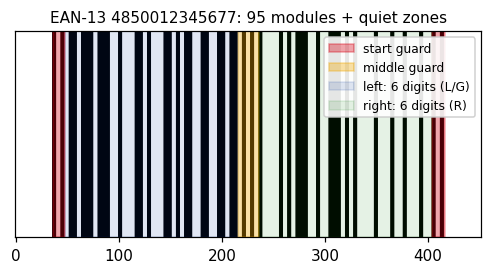

In [5]:
def encode_ean13(digits13: str) -> str:
    """13 digits -> string of 95 '0'/'1' modules (1 = bar)."""
    assert len(digits13) == 13 and digits13.isdigit()
    assert check_digit(digits13[:12]) == digits13[12], "check digit does not match"
    first, left, right = digits13[0], digits13[1:7], digits13[7:]
    modules = "101"                                   # start guard
    for d, p in zip(left, PARITY[first]):
        modules += (L_CODES if p == "L" else G_CODES)[d]
    modules += "01010"                                # middle guard
    for d in right:
        modules += R_CODES[d]
    modules += "101"                                  # end guard
    assert len(modules) == 95
    return modules


def render(modules: str, module_px: int = 4, height_px: int = 200,
           quiet_modules: int = 9) -> np.ndarray:
    """Module string -> grayscale image: white paper, black bars.

    quiet_modules is a symmetric 9 for simplicity; the spec's real quiet zones
    are asymmetric (11 left, 7 right) and our decoder never relies on either.
    """
    row = np.full(2 * quiet_modules + len(modules), 255, dtype=np.uint8)
    for i, m in enumerate(modules):
        if m == "1":
            row[quiet_modules + i] = 0
    row = np.repeat(row, module_px)
    return np.tile(row, (height_px, 1))


DEMO_EAN = "4850012345677"          # the Armenian-prefix code from section 1
demo_img = render(encode_ean13(DEMO_EAN))

# anatomy plot: guards highlighted
fig, ax = plt.subplots(figsize=(10, 2.6))
ax.imshow(demo_img)
q, m = 9 * 4, 4                     # quiet-zone px, module px
for lo, hi, color, label in [(0, 3, ARMRED, "start guard"),
                             (45, 50, ARMORANGE, "middle guard"),
                             (92, 95, ARMRED, "end guard")]:
    ax.axvspan(q + lo * m, q + hi * m, color=color, alpha=0.35,
               label=label if "end" not in label else None)
ax.axvspan(q + 3 * m, q + 45 * m, color=ARMBLUE, alpha=0.12, label="left: 6 digits (L/G)")
ax.axvspan(q + 50 * m, q + 92 * m, color="green", alpha=0.10, label="right: 6 digits (R)")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set_title(f"EAN-13 {DEMO_EAN}: 95 modules + quiet zones", fontsize=10)
ax.set_yticks([])
plt.tight_layout()
plt.show()


The same digit produces *different bars* depending on where it sits - here is 7 in all
three alphabets. This is why you cannot decode a barcode by pattern-matching bars to
digits one-to-one: the mapping depends on position, and (for L vs G) on the hidden first
digit.


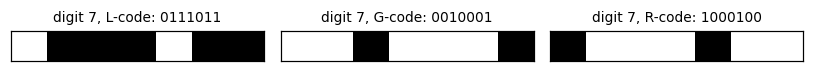

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(7.5, 1.5))
for ax, (name, table) in zip(axes, [("L", L_CODES), ("G", G_CODES), ("R", R_CODES)]):
    strip = np.repeat([[0 if c == "1" else 255 for c in table["7"]]], 10, axis=0)
    ax.imshow(np.repeat(strip, 12, axis=1).astype(np.uint8), vmin=0, vmax=255)
    ax.set_title(f'digit 7, {name}-code: {table["7"]}', fontsize=9)
    ax.set_xticks([]), ax.set_yticks([])
plt.tight_layout()
plt.show()


### Watch the encoder work

`encode_ean13` makes exactly three moves, and it is worth seeing each on a real code:

1. look up the **parity pattern** for the (hidden) first digit;
2. encode the six left-half digits, each through the alphabet (L or G) its position
   demands;
3. encode the six right-half digits through R, and wrap everything in the guards.

The trace prints those moves; the figure below it re-draws our barcode with every
digit's 7-module span marked - digit above the line, alphabet below. Two things to
notice: the digit **5** appears once in each half and gets completely different bars,
and reading the alphabet row of the left half left-to-right spells the parity pattern
that secretly stores the first digit.


EAN 4850012345677: first digit 4 -> left-half parity LGLLGG

position   digit   alphabet  modules
2          8       L         0110111
3          5       G         0111001
4          0       L         0001101
5          0       L         0001101
6          1       G         0110011
7          2       G         0011011
          -- middle guard: 01010 --
8          3       R         1000010
9          4       R         1011100
10         5       R         1001110
11         6       R         1010000
12         7       R         1000100
13         7       R         1000100


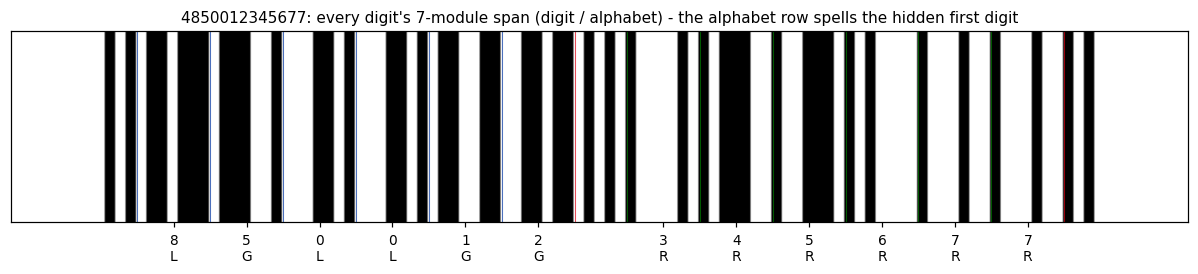

In [7]:
first, left, right = DEMO_EAN[0], DEMO_EAN[1:7], DEMO_EAN[7:]
print(f"EAN {DEMO_EAN}: first digit {first} -> left-half parity {PARITY[first]}\n")
print(f"{'position':<10} {'digit':<7} {'alphabet':<9} modules")
for i, (d, p) in enumerate(zip(left, PARITY[first]), start=2):
    print(f"{i:<10} {d:<7} {p:<9} {(L_CODES if p == 'L' else G_CODES)[d]}")
print(" " * 10 + "-- middle guard: 01010 --")
for i, d in enumerate(right, start=8):
    print(f"{i:<10} {d:<7} {'R':<9} {R_CODES[d]}")

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.imshow(demo_img, aspect="auto")
q, m = 9 * 4, 4
centers, labels = [], []
for k, (d, p) in enumerate(zip(left, PARITY[first])):
    lo = 3 + 7 * k
    ax.axvline(q + lo * m, color=ARMBLUE, lw=0.7, alpha=0.7)
    centers.append(q + (lo + 3.5) * m)
    labels.append(f"{d}\n{p}")
for k, d in enumerate(right):
    lo = 50 + 7 * k
    ax.axvline(q + lo * m, color="green", lw=0.7, alpha=0.7)
    centers.append(q + (lo + 3.5) * m)
    labels.append(f"{d}\nR")
for lo in (45, 92):
    ax.axvline(q + lo * m, color=ARMRED, lw=0.7, alpha=0.7)
ax.set_xticks(centers)
ax.set_xticklabels(labels, fontsize=9)
ax.set_yticks([])
ax.set_title(f"{DEMO_EAN}: every digit's 7-module span (digit / alphabet) - "
             "the alphabet row spells the hidden first digit", fontsize=10)
plt.tight_layout()
plt.show()


## 3. First decode - image to signal to digits

A 2D barcode image is really a **1D signal** repeated vertically. So the whole decoding
problem collapses to: take one horizontal row of pixels (a *scanline*), and turn it back
into digits. Look at what the machine sees:


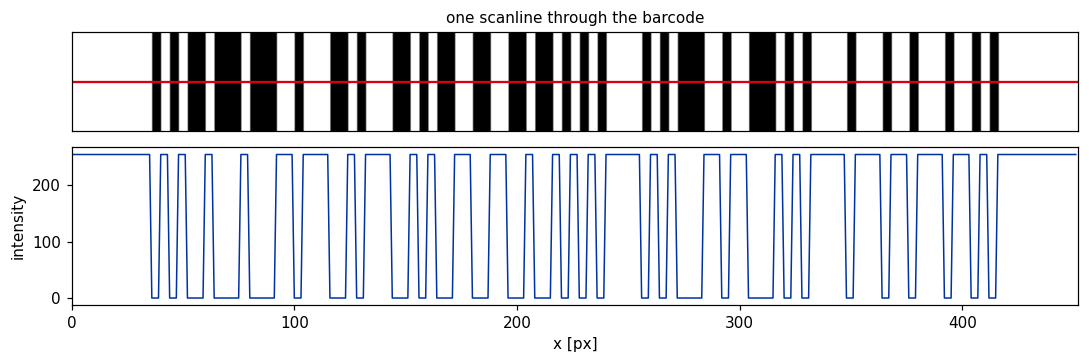

In [8]:
scan = demo_img[demo_img.shape[0] // 2].astype(float)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 3.4),
                               gridspec_kw={"height_ratios": [1, 1.6]})
ax1.imshow(demo_img, aspect="auto")
ax1.axhline(demo_img.shape[0] // 2, color=ARMRED, lw=1.5)
ax1.set_yticks([]), ax1.set_xticks([])
ax1.set_title("one scanline through the barcode", fontsize=10)
ax2.plot(scan, color=ARMBLUE, lw=1)
ax2.set_xlim(0, len(scan)), ax2.set_ylabel("intensity")
ax2.set_xlabel("x [px]")
plt.tight_layout()
plt.show()


### Runs, and why widths beat positions

Threshold the scanline (dark = bar) and compress it to **runs**: maximal stretches of
same-color pixels, each with a length. A clean EAN-13 between its quiet zones is exactly
**59 runs**: 3 (start guard) + 24 (6 left digits x 4 runs each) + 5 (middle) + 24 (right)
+ 3 (end).

Everything downstream works on run *widths*, never absolute positions. Widths divide out
scale: a digit's 4 runs always sum to 7 modules, so `widths / widths.sum() * 7` recovers
the module pattern whether one module is 3 pixels or 30. The barcode carries its own
ruler.


In [9]:
def run_lengths(bits: np.ndarray):
    """1D 0/1 array -> (values, lengths) of consecutive runs."""
    change = np.flatnonzero(np.diff(bits)) + 1
    starts = np.concatenate([[0], change])
    ends = np.concatenate([change, [len(bits)]])
    return bits[starts], (ends - starts).astype(float)


thresh = (scan.min() + scan.max()) / 2          # global midpoint, for now
bits = (scan < thresh).astype(np.uint8)         # 1 = dark = bar
vals, lens = run_lengths(bits)
print(f"runs on the scanline (incl. quiet zones): {len(vals)}")
print("first 10 runs (value, px):", [(int(v), int(l)) for v, l in zip(vals[:10], lens[:10])])
print("-> after dropping the two white quiet-zone runs:", len(vals) - 2, "runs")


runs on the scanline (incl. quiet zones): 61
first 10 runs (value, px): [(0, 36), (1, 4), (0, 4), (1, 4), (0, 4), (1, 8), (0, 4), (1, 12), (0, 4), (1, 12)]
-> after dropping the two white quiet-zone runs: 59 runs


### Matching digits by nearest signature

Each digit is 4 runs. Normalise them to 7 modules and compare against the 4-run
signatures of all candidate codes - `L` and `G` for the left half, `R` for the right.
We take the **nearest** signature rather than demanding an exact integer match; on clean
images it is the same thing, and on blurry ones (where a 2-module bar might measure 1.7)
the nearest match keeps working long after exact rounding has failed.

Then the two structural gates: the six left-half table choices must spell a legal
**parity pattern** (which reveals digit #1), and the full 13 digits must pass the
**check digit**.

The whole decoder is just bookkeeping over the 59 runs - keep this map next to the code:

| runs | what they are |
|---|---|
| 0-2 | start guard: bar, space, bar |
| 3-26 | left half: 6 digits x 4 runs |
| 27-31 | middle guard |
| 32-55 | right half: 6 digits x 4 runs |
| 56-58 | end guard: bar, space, bar |


In [10]:
def _signature(code: str) -> np.ndarray:
    _, sig = run_lengths(np.frombuffer(code.encode(), dtype=np.uint8) - ord("0"))
    assert len(sig) == 4
    return sig


SIGNATURES = {name: {d: _signature(c) for d, c in table.items()}
              for name, table in [("L", L_CODES), ("G", G_CODES), ("R", R_CODES)]}


def match_digit(widths4, table_names):
    """4 run widths -> (digit, table_name, distance) of the nearest signature."""
    w = widths4 / widths4.sum() * 7.0
    best = ("?", "?", np.inf)
    for name in table_names:
        for digit, sig in SIGNATURES[name].items():
            dist = float(np.abs(w - sig).sum())
            if dist < best[2]:
                best = (digit, name, dist)
    return best


def decode_runs(vals, lens):
    """A 59-run window (bar-first, bar-last) -> (digits13 or None, reason)."""
    if len(vals) != 59 or vals[0] != 1 or vals[-1] != 1:
        return None, "not a 59-run bar-to-bar window"
    digits, parities = [], []
    for k in range(6):                                   # left half: runs 3..26
        d, t, _ = match_digit(lens[3 + 4 * k: 7 + 4 * k], ("L", "G"))
        digits.append(d)
        parities.append(t)
    first = [f for f, p in PARITY.items() if p == "".join(parities)]
    if not first:
        return None, f"parity {''.join(parities)} is not legal"
    for k in range(6):                                   # right half: runs 32..55
        d, _, _ = match_digit(lens[32 + 4 * k: 36 + 4 * k], ("R",))
        digits.append(d)
    result = first[0] + "".join(digits)
    if check_digit(result[:12]) != result[12]:
        return None, f"check digit rejects {result}"
    return result, "ok"


def decode_scanline(scan, bits=None):
    """Grayscale scanline -> (digits13 or None, reason). Global threshold."""
    if bits is None:
        thresh = (scan.min() + scan.max()) / 2.0
        bits = (scan < thresh).astype(np.uint8)
    vals, lens = run_lengths(bits)
    if len(vals) >= 2 and vals[0] == 0:                 # strip quiet zones
        vals, lens = vals[1:], lens[1:]
    if len(vals) >= 2 and vals[-1] == 0:
        vals, lens = vals[:-1], lens[:-1]
    return decode_runs(vals, lens)


result, reason = decode_scanline(scan)
print(f"decoded: {result}   ({reason})")
assert result == DEMO_EAN


decoded: 4850012345677   (ok)


### One digit under the microscope

That was a lot of machinery in one gulp. Slow down and watch a single digit go through
the matcher: the first left-half digit lives in runs 3-6 (see the map above) - four
pixel widths, normalised to sum to 7 modules, then compared against all twenty
candidate signatures. Note that the matcher does not know in advance whether the digit
was encoded with L or G - the *match discovers the alphabet*, and that discovery is the
parity bit that will reveal the first digit.


pixel widths [ 4  8  4 12] -> modules [1. 2. 1. 3.]
  candidate 8/L: signature [1 2 1 3], distance 0.00
  candidate 0/G: signature [1 1 2 3], distance 2.00
  candidate 1/G: signature [1 2 2 2], distance 2.00


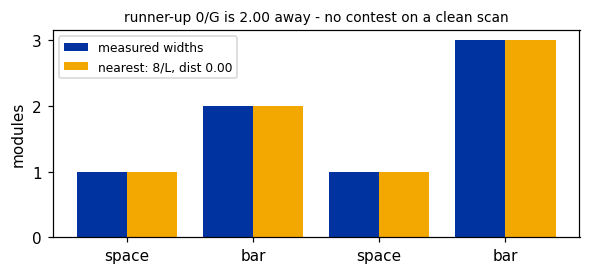

In [11]:
bits = (scan < (scan.min() + scan.max()) / 2).astype(np.uint8)
v, l = run_lengths(bits)
v, l = v[1:-1], l[1:-1]                     # drop the two quiet-zone runs
w = l[3:7]                                  # first left-half digit
norm = w / w.sum() * 7
print(f"pixel widths {w.astype(int)} -> modules {np.round(norm, 2)}")
ranked = sorted((float(np.abs(norm - sig).sum()), d, t)
                for t in ("L", "G") for d, sig in SIGNATURES[t].items())
for dist, d, t in ranked[:3]:
    print(f"  candidate {d}/{t}: signature {SIGNATURES[t][d].astype(int)}, "
          f"distance {dist:.2f}")

fig, ax = plt.subplots(figsize=(5.6, 2.6))
x = np.arange(4)
dist0, d0, t0 = ranked[0]
dist1, d1, t1 = ranked[1]
ax.bar(x - 0.2, norm, 0.4, color=ARMBLUE, label="measured widths")
ax.bar(x + 0.2, SIGNATURES[t0][d0], 0.4, color=ARMORANGE,
       label=f"nearest: {d0}/{t0}, dist {dist0:.2f}")
ax.set_xticks(x, ["space", "bar", "space", "bar"])
ax.set_ylabel("modules")
ax.set_title(f"runner-up {d1}/{t1} is {dist1:.2f} away - no contest on a clean scan",
             fontsize=9)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Now the same idea across all twelve digits - a chatty clone of `decode_runs` that
narrates every step of one read, including the two gates at the end. If any part of
`decode_scanline` felt like a black box, this output is the box opened:


In [12]:
def decode_verbose(scan):
    thresh = (scan.min() + scan.max()) / 2
    bits = (scan < thresh).astype(np.uint8)
    vals, lens = run_lengths(bits)
    vals, lens = vals[1:-1], lens[1:-1]
    print(f"{len(vals)} runs; module estimate = total width / 95 = "
          f"{lens.sum() / 95:.2f} px")
    digits, parities = [], []
    for half, base, tables in [("left ", 3, ("L", "G")), ("right", 32, ("R",))]:
        for k in range(6):
            widths = lens[base + 4 * k: base + 4 * (k + 1)]
            d, t, dist = match_digit(widths, tables)
            if half == "left ":
                parities.append(t)
            digits.append(d)
            print(f"  {half} digit {k + 1}: widths {widths.astype(int)} -> "
                  f"{d}/{t}  (dist {dist:.2f})")
    par = "".join(parities)
    first = [f for f, p in PARITY.items() if p == par][0]
    print(f"parity pattern {par} -> hidden first digit {first}")
    result = first + "".join(digits)
    ok = check_digit(result[:12]) == result[12]
    print(f"check digit: computed {check_digit(result[:12])}, read {result[12]} -> "
          f"{'VALID' if ok else 'INVALID'}")
    return result


assert decode_verbose(scan) == DEMO_EAN


59 runs; module estimate = total width / 95 = 4.00 px
  left  digit 1: widths [ 4  8  4 12] -> 8/L  (dist 0.00)
  left  digit 2: widths [ 4 12  8  4] -> 5/G  (dist 0.00)
  left  digit 3: widths [12  8  4  4] -> 0/L  (dist 0.00)
  left  digit 4: widths [12  8  4  4] -> 0/L  (dist 0.00)
  left  digit 5: widths [4 8 8 8] -> 1/G  (dist 0.00)
  left  digit 6: widths [8 8 4 8] -> 2/G  (dist 0.00)
  right digit 1: widths [ 4 16  4  4] -> 3/R  (dist 0.00)
  right digit 2: widths [ 4  4 12  8] -> 4/R  (dist 0.00)
  right digit 3: widths [ 4  8 12  4] -> 5/R  (dist 0.00)
  right digit 4: widths [ 4  4  4 16] -> 6/R  (dist 0.00)
  right digit 5: widths [ 4 12  4  8] -> 7/R  (dist 0.00)
  right digit 6: widths [ 4 12  4  8] -> 7/R  (dist 0.00)
parity pattern LGLLGG -> hidden first digit 4
check digit: computed 7, read 7 -> VALID


It reads back exactly what we encoded. One success is an anecdote; run the full loop -
random codes, encode, render, decode:


In [13]:
rng = np.random.default_rng(SEED)


def random_ean(rng):
    b = "".join(rng.choice(list("0123456789"), 12))
    return b + check_digit(b)


n_ok = 0
for _ in range(200):
    ean = random_ean(rng)
    img = render(encode_ean13(ean), module_px=3)
    res, _ = decode_scanline(img[img.shape[0] // 2].astype(float))
    n_ok += res == ean
print(f"clean round-trip: {n_ok} / 200")


clean round-trip: 200 / 200


### Upside down?

Predict first: you hand the scanner the can upside down. The scanline arrives
**reversed**. How does it know?

The parity design from section 2 answers it. Read tail-first, the right half's R-codes
arrive reversed - and a reversed R-code *is* a G-code, so the left six digits of a
backwards read produce a parity signature drawn from the wrong distribution; on top of
that, the check digit gets a veto. So the honest strategy is: **try both directions and
let the gates decide**. Measure how often a backwards read sneaks past both gates:


In [14]:
def decode_bidirectional(scan, bits=None, decoder=decode_scanline):
    """Try forward, then reversed. The parity + checksum gates arbitrate."""
    res, _ = decoder(scan, bits=bits)
    if res is not None:
        return res, "forward"
    res, _ = decoder(scan[::-1], bits=None if bits is None else bits[::-1])
    if res is not None:
        return res, "reversed"
    return None, None


rng = np.random.default_rng(SEED)
n_sneak = 0
for _ in range(500):
    ean = random_ean(rng)
    img = render(encode_ean13(ean), module_px=3)
    res, _ = decode_scanline(img[50][::-1].astype(float))   # forward parse, flipped code
    n_sneak += res is not None
print(f"backwards reads that pass a FORWARD parse: {n_sneak} / 500")

res, direction = decode_bidirectional(demo_img[50][::-1].astype(float))
print(f"bidirectional decode of a flipped scan: {res}  (read {direction})")


backwards reads that pass a FORWARD parse: 0 / 500
bidirectional decode of a flipped scan: 4850012345677  (read reversed)


## 4. Break it - and fix it, one measured step at a time

Real images are not 255-vs-0 crisp. Three enemies, each a camera reality:

- **blur** - bad focus, motion;
- **noise** - dim light, high ISO;
- **an illumination ramp** - one side of the package in shadow.

We will hit the same 30 test barcodes with each, and fix failures one mechanism at a
time. The rule of the game (it is the rule of this whole course): *no fix enters the
pipeline without a measurement showing what it buys and what it costs.*


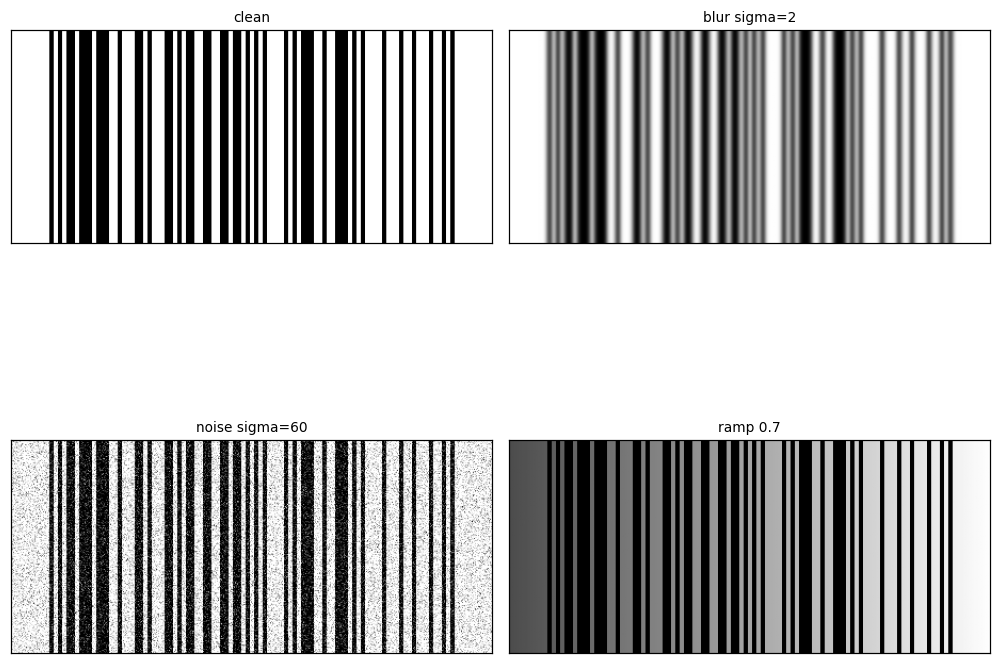

In [15]:
def degrade(img, blur_sigma=0.0, noise_sigma=0.0, ramp=0.0, rng=None):
    out = img.astype(np.float64)
    if blur_sigma > 0:
        out = cv2.GaussianBlur(out, (0, 0), blur_sigma)
    if ramp > 0:          # left edge keeps only (1 - ramp) of its brightness
        out *= np.linspace(1 - ramp, 1.0, out.shape[1])[None, :]
    if noise_sigma > 0:
        out += rng.normal(0, noise_sigma, out.shape)
    return np.clip(out, 0, 255).astype(np.uint8)


rng = np.random.default_rng(SEED)
gallery = [demo_img,
           degrade(demo_img, blur_sigma=2),
           degrade(demo_img, noise_sigma=60, rng=rng),
           degrade(demo_img, ramp=0.7)]
show(gallery, ["clean", "blur sigma=2", "noise sigma=60", "ramp 0.7"], ncols=2, size=4.6)


### The test bench

30 random codes at `module_px=3` (bars 3-12 px wide - a barcode occupying a modest chunk
of a phone photo), 13 degradation scenarios, **frozen once**: every method below decodes
the *same* images, so columns are comparable. The score is exact 13-digit matches out
of 30.

Baseline method: one scanline through the middle, global threshold - exactly what worked
200/200 in section 3.


In [16]:
rng = np.random.default_rng(SEED)
TEST_CODES = [random_ean(rng) for _ in range(30)]
CLEAN = {e: render(encode_ean13(e), module_px=3, height_px=120) for e in TEST_CODES}

SCENARIOS = [
    ("clean",             dict()),
    ("blur s=1",          dict(blur_sigma=1)),
    ("blur s=2",          dict(blur_sigma=2)),
    ("blur s=3",          dict(blur_sigma=3)),
    ("noise s=30",        dict(noise_sigma=30)),
    ("noise s=60",        dict(noise_sigma=60)),
    ("noise s=90",        dict(noise_sigma=90)),
    ("noise s=120",       dict(noise_sigma=120)),
    ("blur1 + noise30",   dict(blur_sigma=1, noise_sigma=30)),
    ("blur2 + noise60",   dict(blur_sigma=2, noise_sigma=60)),
    ("ramp 0.7",          dict(ramp=0.7)),
    ("ramp + noise30",    dict(ramp=0.7, noise_sigma=30)),
    ("ramp + noise60",    dict(ramp=0.7, noise_sigma=60)),
]
DEGRADED = {name: [degrade(CLEAN[e], rng=rng, **kw) for e in TEST_CODES]
            for name, kw in SCENARIOS}

RESULTS = {}          # method label -> {scenario: n correct}


def measure(label, decode_img):
    """Score decode_img over the frozen bench and print the growing table."""
    RESULTS[label] = {name: sum(decode_img(img) == e
                                for img, e in zip(DEGRADED[name], TEST_CODES))
                      for name, _ in SCENARIOS}
    head = f"{'scenario':<17}" + "".join(f"{c:>16}" for c in RESULTS)
    print(head)
    print("-" * len(head))
    for name, _ in SCENARIOS:
        print(f"{name:<17}" + "".join(f"{RESULTS[c][name]:>13}/30" for c in RESULTS))


measure("1 line", lambda img: decode_bidirectional(
    img[img.shape[0] // 2].astype(float))[0])


scenario                   1 line
---------------------------------
clean                       30/30
blur s=1                    30/30
blur s=2                    30/30
blur s=3                     0/30
noise s=30                  30/30
noise s=60                   0/30
noise s=90                   0/30
noise s=120                  0/30
blur1 + noise30             27/30
blur2 + noise60              0/30
ramp 0.7                     0/30
ramp + noise30               0/30
ramp + noise60               0/30


Read the failures, not the successes. Three distinct collapse modes:

- **blur s=3**: 1-module bars (3 px) smear into their neighbours; runs merge and the
  59-run structure is gone before any digit matching starts.
- **noise s=60+**: salt-and-pepper flips pixels across the global threshold, shattering
  runs.
- **ramp 0.7**: the *one global threshold* is the casualty. A cutoff bright enough for
  the shadowed left side calls the sunny side's spaces "bars". Nothing survives.

Fix one thing at a time, cheapest first.

### Fix 1: more scanlines + voting

One scanline is one witness; take twenty-one, spread over the barcode's height, and let
the reads that pass the gates **vote**. Why this works is best seen, not told - here is
a noise s=60 image with every scanline colored by its fate:


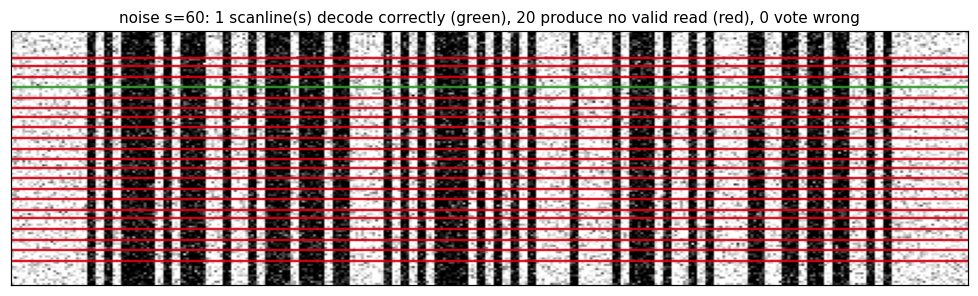

In [17]:
img, truth = DEGRADED["noise s=60"][0], TEST_CODES[0]
rows = np.linspace(img.shape[0] * 0.1, img.shape[0] * 0.9, 21).astype(int)
verdicts = []
for r in rows:
    res, _ = decode_bidirectional(img[r].astype(float))
    verdicts.append("correct" if res == truth else ("WRONG" if res else "no read"))

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.imshow(img, aspect="auto")
for r, vd in zip(rows, verdicts):
    ax.axhline(r, color="#2a9d2a" if vd == "correct" else ARMRED, lw=1.6, alpha=0.9)
ax.set_xticks([]), ax.set_yticks([])
counts = Counter(verdicts)
ax.set_title(f"noise s=60: {counts['correct']} scanline(s) decode correctly (green), "
             f"{counts['no read']} produce no valid read (red), "
             f"{counts['WRONG']} vote wrong", fontsize=10)
plt.tight_layout()
plt.show()


This is not a majority outvoting a minority - usually a **single** row survives and
twenty fail. It works anyway because the gates from section 3 turn every bad row into
*silence*, not into a wrong answer: zero wrong votes in the picture above. An election
where every mistaken voter stays home is easy to win; one honest vote is enough. So
"more scanlines" is really "more chances for one clean read", with the check digit
guaranteeing that chances are all we accumulate - not risk.


In [18]:
def vote_lines(img, decode_line, n_lines=21):
    votes = Counter()
    for r in np.linspace(img.shape[0] * 0.1, img.shape[0] * 0.9, n_lines).astype(int):
        res = decode_line(img, r)
        if res is not None:
            votes[res] += 1
    return votes.most_common(1)[0][0] if votes else None


measure("21 lines", lambda img: vote_lines(
    img, lambda im, r: decode_bidirectional(im[r].astype(float))[0]))


scenario                   1 line        21 lines
-------------------------------------------------
clean                       30/30           30/30
blur s=1                    30/30           30/30
blur s=2                    30/30           30/30
blur s=3                     0/30            0/30
noise s=30                  30/30           30/30
noise s=60                   0/30           11/30
noise s=90                   0/30            0/30
noise s=120                  0/30            0/30
blur1 + noise30             27/30           30/30
blur2 + noise60              0/30            0/30
ramp 0.7                     0/30            0/30
ramp + noise30               0/30            0/30
ramp + noise60               0/30            0/30


Noise s=60 goes from dead to partly rescued - *partly*, because "one surviving row" is
a coin flip, and the rescued 11/30 are simply the images where at least one witness made
it. Everything else that already worked stays. But the ramp column has not moved - all
21 rows share the same lighting, so all 21 fail *identically*. Voting only helps against
independent failures. The ramp needs a different weapon.

### Fix 2: an adaptive threshold

Replace the one global cutoff with a **local** one: slide a window along the scanline,
and call a pixel "bar" when it is darker than its own neighbourhood mean (minus a small
offset so flat paper does not flicker). Shadows vary slowly, bars vary fast - a local
mean tracks the first and not the second.

See the mechanism before measuring it. One ramp scanline, both threshold candidates
drawn over it, and the bar/space decision each one produces:


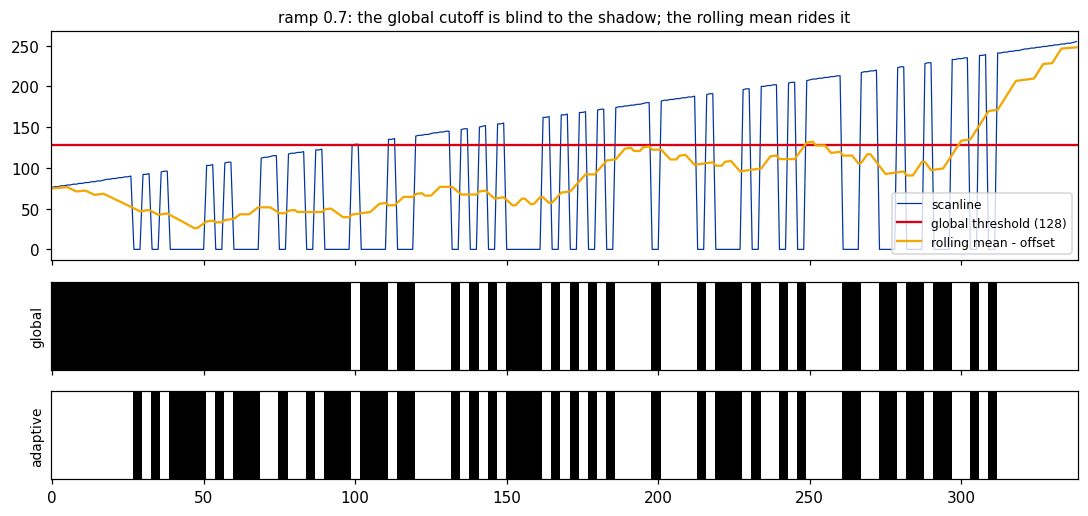

In [19]:
s = DEGRADED["ramp 0.7"][0][60].astype(float)
g_thr = (s.min() + s.max()) / 2
win = max(3, int(len(s) / 8)) | 1
local_mean = np.convolve(np.pad(s, win // 2, mode="edge"),
                         np.ones(win) / win, mode="valid")

fig, axes = plt.subplots(3, 1, figsize=(10, 4.8), sharex=True,
                         gridspec_kw={"height_ratios": [2.6, 1, 1]})
axes[0].plot(s, color=ARMBLUE, lw=0.8, label="scanline")
axes[0].axhline(g_thr, color=ARMRED, lw=1.5, label=f"global threshold ({g_thr:.0f})")
axes[0].plot(local_mean - 4, color=ARMORANGE, lw=1.5, label="rolling mean - offset")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title("ramp 0.7: the global cutoff is blind to the shadow; "
                  "the rolling mean rides it", fontsize=10)
for ax, mask, name in [(axes[1], s >= g_thr, "global"),
                       (axes[2], s >= local_mean - 4, "adaptive")]:
    ax.imshow(np.tile(mask.astype(np.uint8) * 255, (10, 1)), aspect="auto",
              vmin=0, vmax=255)
    ax.set_ylabel(name, fontsize=9)
    ax.set_yticks([])
plt.tight_layout()
plt.show()


The middle strip is what the decoder has been fed so far: the shadowed left half turns
into one giant "bar", and the read is unrecoverable before digit matching even starts.
The bottom strip is the same scanline through the local threshold - bars all the way
across. Now the measurement - and predict first: what does that tiny fixed offset do to
the *noise* rows?


In [20]:
def binarize_adaptive(scan, frac=8, offset=4.0):
    """1 = bar, by comparison against a rolling local mean."""
    win = max(3, int(len(scan) / frac)) | 1
    kernel = np.ones(win) / win
    local_mean = np.convolve(np.pad(scan, win // 2, mode="edge"), kernel, mode="valid")
    return (scan < local_mean - offset).astype(np.uint8)


measure("21 adaptive", lambda img: vote_lines(
    img, lambda im, r: decode_bidirectional(
        im[r].astype(float), bits=binarize_adaptive(im[r].astype(float)))[0]))


scenario                   1 line        21 lines     21 adaptive
-----------------------------------------------------------------
clean                       30/30           30/30           30/30
blur s=1                    30/30           30/30           27/30
blur s=2                    30/30           30/30            0/30
blur s=3                     0/30            0/30            0/30
noise s=30                  30/30           30/30            0/30
noise s=60                   0/30           11/30            0/30
noise s=90                   0/30            0/30            0/30
noise s=120                  0/30            0/30            0/30
blur1 + noise30             27/30           30/30            0/30
blur2 + noise60              0/30            0/30            0/30
ramp 0.7                     0/30            0/30           30/30
ramp + noise30               0/30            0/30            0/30
ramp + noise60               0/30            0/30            0/30


The ramp is *fixed* - and half the table just caught fire. The tiny offset (4 gray
levels) that makes the adaptive threshold sensitive to faint bars also makes every noise
fluctuation above 4 levels a phantom bar; and near blurred edges, pixels hover exactly
around their local mean. The global threshold, by pooling the whole line, was quietly
*robust* to both. Watch it lose - the same three-panel view, now on noise s=30, a
scenario the global threshold read 30/30:


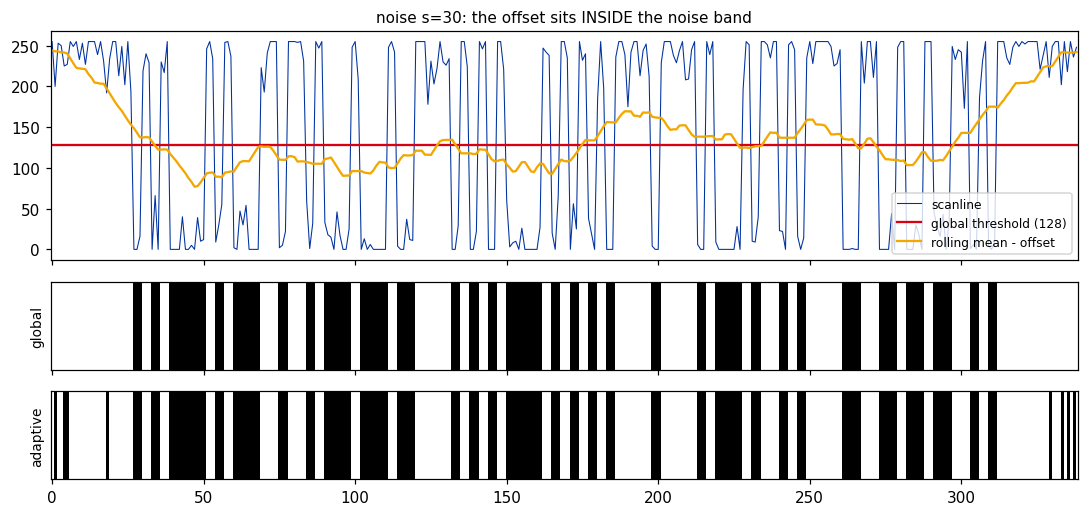

In [21]:
s = DEGRADED["noise s=30"][0][60].astype(float)
g_thr = (s.min() + s.max()) / 2
local_mean = np.convolve(np.pad(s, win // 2, mode="edge"),
                         np.ones(win) / win, mode="valid")

fig, axes = plt.subplots(3, 1, figsize=(10, 4.8), sharex=True,
                         gridspec_kw={"height_ratios": [2.6, 1, 1]})
axes[0].plot(s, color=ARMBLUE, lw=0.7, label="scanline")
axes[0].axhline(g_thr, color=ARMRED, lw=1.5, label=f"global threshold ({g_thr:.0f})")
axes[0].plot(local_mean - 4, color=ARMORANGE, lw=1.5, label="rolling mean - offset")
axes[0].legend(fontsize=8, loc="lower right")
axes[0].set_title("noise s=30: the offset sits INSIDE the noise band", fontsize=10)
for ax, mask, name in [(axes[1], s >= g_thr, "global"),
                       (axes[2], s >= local_mean - 4, "adaptive")]:
    ax.imshow(np.tile(mask.astype(np.uint8) * 255, (10, 1)), aspect="auto",
              vmin=0, vmax=255)
    ax.set_ylabel(name, fontsize=9)
    ax.set_yticks([])
plt.tight_layout()
plt.show()


The global strip is clean bars; the adaptive strip is peppered with phantom flecks -
every noise excursion 4 gray levels below its local mean becomes a micro-bar, the run
structure shatters, and the parse dies.

That is the real lesson of this section: **every preprocessing choice is a bet on which
enemy you are facing.** Global bets on even lighting; adaptive bets on low noise. Neither
dominates.

### Fix 3: stop choosing - cascade, and let the check digit referee

We do not have to pick one. Try the cheap parse first (global); if no read passes the
gates, re-try adaptive; then smoothed + adaptive (a small Gaussian tames the noise the
offset cannot). The check digit makes this *safe*: a stage that fails simply produces no
valid read, and we fall through to the next. Stacking strategies costs attempts, never
correctness (we will meet the one exception - the 1/10 fluke - in section 8).


In [22]:
def smooth1d(scan, sigma=1.5):
    r = int(3 * sigma)
    x = np.arange(-r, r + 1)
    k = np.exp(-x ** 2 / (2 * sigma ** 2))
    return np.convolve(np.pad(scan, r, mode="edge"), k / k.sum(), mode="valid")


def cascade_line(scan, decoder=decode_scanline):
    """global -> adaptive -> smooth+adaptive; first read that passes the gates wins."""
    for prep in ("global", "adaptive", "smooth+adaptive"):
        s = smooth1d(scan) if prep == "smooth+adaptive" else scan
        bits = binarize_adaptive(s) if prep != "global" else None
        res, _ = decode_bidirectional(s, bits=bits, decoder=decoder)
        if res is not None:
            return res
    return None


measure("cascade", lambda img: vote_lines(
    img, lambda im, r: cascade_line(im[r].astype(float))))


scenario                   1 line        21 lines     21 adaptive         cascade
---------------------------------------------------------------------------------
clean                       30/30           30/30           30/30           30/30
blur s=1                    30/30           30/30           27/30           30/30
blur s=2                    30/30           30/30            0/30           30/30
blur s=3                     0/30            0/30            0/30            0/30
noise s=30                  30/30           30/30            0/30           30/30
noise s=60                   0/30           11/30            0/30           14/30
noise s=90                   0/30            0/30            0/30            0/30
noise s=120                  0/30            0/30            0/30            0/30
blur1 + noise30             27/30           30/30            0/30           30/30
blur2 + noise60              0/30            0/30            0/30            0/30
ramp 0.7        

Best of both columns, as ordered: the noise rows keep the global threshold's results, the
ramp keeps the adaptive fix. Two failure families left: heavy noise (s=90+), and the
ramp+noise combinations.

### Fix 4: average a band - the barcode's own redundancy

For noise there is a weapon better than voting, and the barcode's geometry hands it to
us: **bars are constant vertically, noise is not.** Average 15 adjacent rows into one
scanline and independent pixel noise shrinks by sqrt(15) ~ 3.9x - before any decoding.
Voting treats rows as independent witnesses; averaging *merges* them into one witness
with far better eyesight.


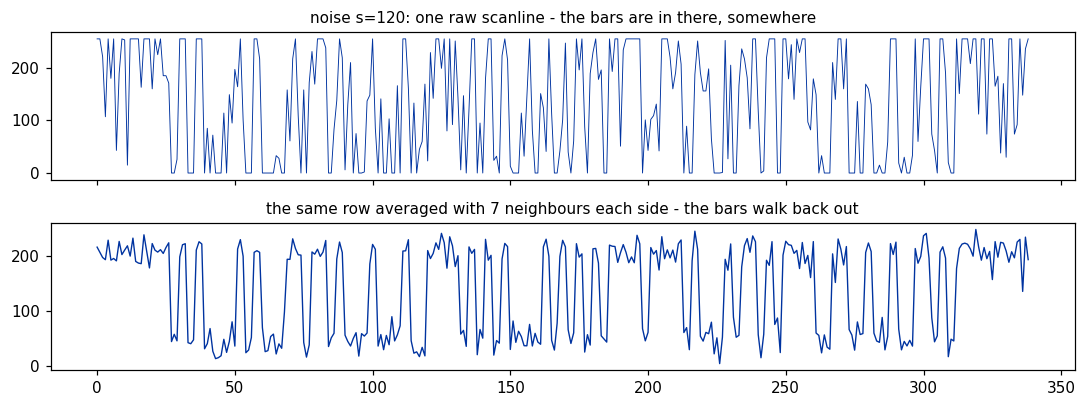

In [23]:
def band_scan(img, r, half=7):
    lo, hi = max(0, r - half), min(img.shape[0], r + half + 1)
    return img[lo:hi].astype(float).mean(axis=0)


noisy = DEGRADED["noise s=120"][0]
r = noisy.shape[0] // 2
fig, axes = plt.subplots(2, 1, figsize=(10, 3.8), sharex=True)
axes[0].plot(noisy[r].astype(float), lw=0.6, color=ARMBLUE)
axes[0].set_title("noise s=120: one raw scanline - the bars are in there, somewhere",
                  fontsize=10)
axes[1].plot(band_scan(noisy, r), lw=0.9, color=ARMBLUE)
axes[1].set_title("the same row averaged with 7 neighbours each side - "
                  "the bars walk back out", fontsize=10)
plt.tight_layout()
plt.show()


No threshold on Earth reads the top signal; the bottom one is almost office-scanner
clean, and all we did was a mean over 15 rows. Now feed the averaged lines through the
cascade:


In [24]:
measure("band cascade", lambda img: vote_lines(
    img, lambda im, r: cascade_line(band_scan(im, r))))


scenario                   1 line        21 lines     21 adaptive         cascade    band cascade
-------------------------------------------------------------------------------------------------
clean                       30/30           30/30           30/30           30/30           30/30
blur s=1                    30/30           30/30           27/30           30/30           30/30
blur s=2                    30/30           30/30            0/30           30/30           30/30
blur s=3                     0/30            0/30            0/30            0/30            0/30
noise s=30                  30/30           30/30            0/30           30/30           30/30
noise s=60                   0/30           11/30            0/30           14/30           30/30
noise s=90                   0/30            0/30            0/30            0/30           30/30
noise s=120                  0/30            0/30            0/30            0/30           30/30
blur1 + noise30     

Noise is *solved* - even s=120, where a single scanline is pure static. What still
resists: **ramp + noise**, plus the blur wall.

### Fix 5: stop trusting the framing - search for the code

Diagnose ramp+noise: after band-averaging, the residual noise is small, but a small
`offset=4` still lets occasional speckles in the *quiet zones* register as phantom
micro-bars. Our decoder demanded "exactly 59 runs after stripping one white run per
side" - one speckle anywhere and the whole parse is off by two runs. The structure was
fine; our *framing assumption* was brittle. (Real photos will break it much harder: the
digits printed under the code, package art, table edges - all become extra runs.)

Here is the crime scene - one ramp+noise scanline, band-averaged and adaptively
binarized, with the run count printed and the left quiet zone zoomed:


runs between the outer whites: 65   (a clean code has 59)


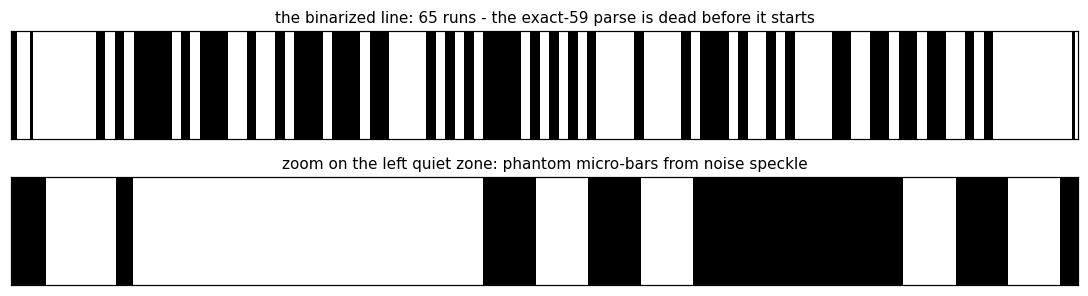

In [25]:
img = DEGRADED["ramp + noise30"][0]
band = band_scan(img, img.shape[0] // 2)
bits = binarize_adaptive(band)
v, l = run_lengths(bits)
n_inner = len(v) - (v[0] == 0) - (v[-1] == 0)
print(f"runs between the outer whites: {n_inner}   (a clean code has 59)")

strip = np.tile((1 - bits) * 255, (14, 1)).astype(np.uint8)
cut = int(len(band) * 0.18)
fig, axes = plt.subplots(2, 1, figsize=(10, 2.8))
axes[0].imshow(strip, aspect="auto", vmin=0, vmax=255)
axes[0].set_title(f"the binarized line: {n_inner} runs - the exact-59 parse "
                  "is dead before it starts", fontsize=10)
axes[1].imshow(strip[:, :cut], aspect="auto", vmin=0, vmax=255)
axes[1].set_title("zoom on the left quiet zone: phantom micro-bars from noise speckle",
                  fontsize=10)
for ax in axes:
    ax.set_xticks([]), ax.set_yticks([])
plt.tight_layout()
plt.show()


The barcode itself is intact - every extra run is quiet-zone speckle. So stop counting
from the edges and find the code by its own structure.

The fix: **slide a 59-run window over the run sequence** and test every position that
starts at a bar. A cheap pre-filter (the six guard runs must be roughly 1 module each,
with the module estimated from the window's total width / 95) rejects most positions
before the expensive digit matching, and the parity + checksum gates confirm the real
one.


In [26]:
def guard_plausible(lens59):
    module = lens59.sum() / 95.0
    guards = np.concatenate([lens59[:3], lens59[-3:]])
    return bool(np.all(guards < 2.5 * module) and np.all(guards > 0.3 * module))


def decode_scanline_search(scan, bits=None):
    """Robust decoder: find the 59-run window anywhere on the scanline."""
    if bits is None:
        thresh = (scan.min() + scan.max()) / 2.0
        bits = (scan < thresh).astype(np.uint8)
    vals, lens = run_lengths(bits)
    for i in np.flatnonzero(vals == 1):
        if i + 59 > len(vals):
            break
        window = lens[i:i + 59]
        if not guard_plausible(window):
            continue
        res, reason = decode_runs(vals[i:i + 59], window)
        if res is not None:
            return res, reason
    return None, "no valid 59-run window"


measure("band + search", lambda img: vote_lines(
    img, lambda im, r: cascade_line(band_scan(im, r), decoder=decode_scanline_search)))


scenario                   1 line        21 lines     21 adaptive         cascade    band cascade   band + search
-----------------------------------------------------------------------------------------------------------------
clean                       30/30           30/30           30/30           30/30           30/30           30/30
blur s=1                    30/30           30/30           27/30           30/30           30/30           30/30
blur s=2                    30/30           30/30            0/30           30/30           30/30           30/30
blur s=3                     0/30            0/30            0/30            0/30            0/30            0/30
noise s=30                  30/30           30/30            0/30           30/30           30/30           30/30
noise s=60                   0/30           11/30            0/30           14/30           30/30           30/30
noise s=90                   0/30            0/30            0/30            0/30       

Every lighting and noise scenario is read. What remains is the blur family: s=3
outright, and most of the blur2+noise60 combination. Is that a decoder weakness or something more
fundamental? Measure the right experiment: same blur, same code, but render the barcode
at twice the module size.


In [27]:
rng = np.random.default_rng(SEED)
for mpx in (3, 6):
    ok = 0
    for e in TEST_CODES:
        img = degrade(render(encode_ean13(e), module_px=mpx, height_px=120),
                      blur_sigma=3, rng=rng)
        ok += vote_lines(img, lambda im, r: cascade_line(
            band_scan(im, r), decoder=decode_scanline_search)) == e
    print(f"blur sigma=3 at module_px={mpx}:  {ok} / 30")


blur sigma=3 at module_px=3:  0 / 30


blur sigma=3 at module_px=6:  30 / 30


Identical blur, opposite outcomes. When the blur radius reaches the module size, adjacent
runs *merge before thresholding* - the information is destroyed in the optics, and no
software downstream can un-merge them reliably. At twice the module size the same blur is
harmless.

**Resolution beats cleverness.** The practical advice hiding in this table: when a
scanner app struggles, you move the phone *closer*. Now you know why - it is not focus,
it is modules-per-pixel. Keep this in mind; it returns in section 7 with a real photo.


## 5. Orientation - ask the gradients

Photos arrive rotated. Everything so far assumed horizontal scanlines crossing vertical
bars; tilt the code 40 degrees and every scanline cuts diagonally through the pattern
and reads garbage.

L16's Sobel filters are the right tool for finding the tilt, because a barcode is an
extreme texture: intensity changes violently **across** the bars and not at all
**along** them. Start by just looking - `gx` is the Sobel response to left-right change,
`gy` to up-down change, exactly the two kernels from the L16 kernel zoo:


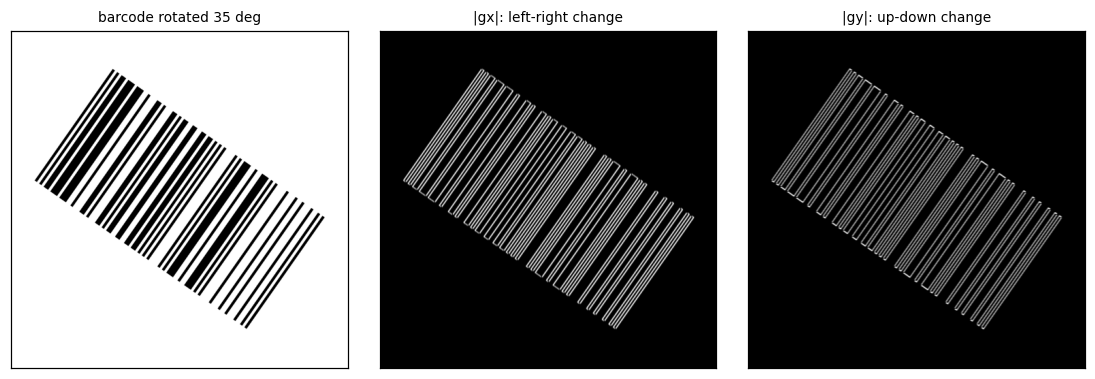

In [28]:
def rotate_image(img, angle_deg, border=255):
    """Rotate on an expanded canvas so corners are not cut off."""
    h, w = img.shape[:2]
    diag = int(np.ceil(np.hypot(h, w)))
    canvas = np.full((diag, diag), border, dtype=img.dtype)
    y0, x0 = (diag - h) // 2, (diag - w) // 2
    canvas[y0:y0 + h, x0:x0 + w] = img
    M = cv2.getRotationMatrix2D((diag / 2, diag / 2), angle_deg, 1.0)
    return cv2.warpAffine(canvas, M, (diag, diag), borderValue=border)


def norm8(a):
    return np.clip(np.abs(a) / np.abs(a).max() * 255, 0, 255).astype(np.uint8)


rot35 = rotate_image(demo_img, -35)
g = rot35.astype(np.float64)
gx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
mag = np.hypot(gx, gy)
show([rot35, norm8(gx), norm8(gy)],
     ["barcode rotated 35 deg", "|gx|: left-right change", "|gy|: up-down change"],
     size=3.4)


Both responses light up, because the tilted bars change in *both* x and y. Neither map
alone knows the angle - the angle lives in the **pair**: at every edge pixel, the
vector `(gx, gy)` points straight across the bar, perpendicular to it. Draw the vectors
on the strongest edges:


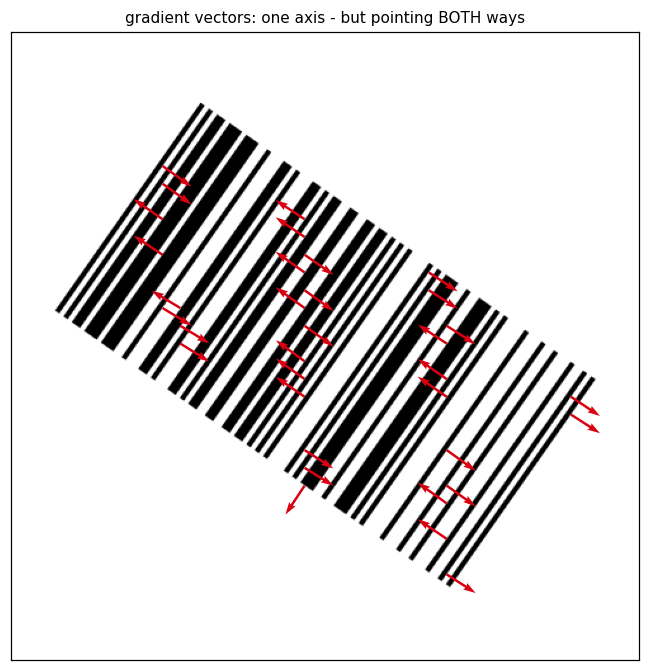

mean gradient vector : (+0.000, +0.000)   <- useless
mean gradient LENGTH :  102.5              <- plenty of signal


In [29]:
step = 14
ys, xs = np.mgrid[step // 2:g.shape[0]:step, step // 2:g.shape[1]:step]
keep = mag[ys, xs] > np.quantile(mag, 0.97)
fig, ax = plt.subplots(figsize=(6.2, 6.2))
ax.imshow(rot35)
ax.quiver(xs[keep], ys[keep], gx[ys, xs][keep], gy[ys, xs][keep],
          color=ARMRED, angles="xy", width=0.004)
ax.set_xticks([]), ax.set_yticks([])
ax.set_title("gradient vectors: one axis - but pointing BOTH ways", fontsize=10)
plt.tight_layout()
plt.show()

print(f"mean gradient vector : ({gx.mean():+.3f}, {gy.mean():+.3f})   <- useless")
print(f"mean gradient LENGTH :  {mag.mean():.1f}              <- plenty of signal")


Every arrow lies on the same axis - and half of them point one way, half the other,
because every black-to-white edge has a white-to-black partner. So the obvious move,
"average the gradient vectors", returns exactly **(0, 0)**: the signal cancels itself.
Yet the average *length* is huge. The information is all there; the **sign** is what
kills the mean. The histogram makes the disease unmistakable:


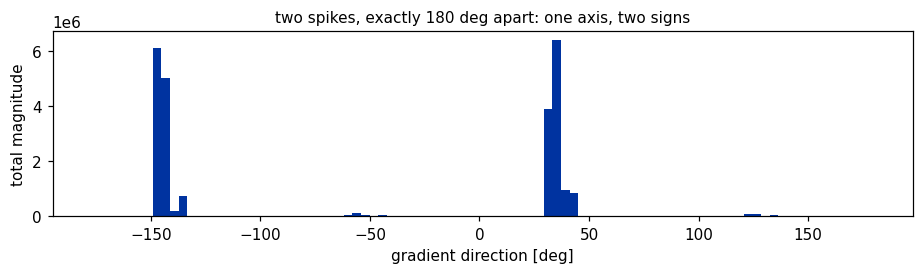

In [30]:
fig, ax = plt.subplots(figsize=(8.5, 2.6))
ax.hist(np.degrees(np.arctan2(gy, gx)).ravel(), bins=90, weights=mag.ravel(),
        color=ARMBLUE)
ax.set_xlabel("gradient direction [deg]")
ax.set_ylabel("total magnitude")
ax.set_title("two spikes, exactly 180 deg apart: one axis, two signs", fontsize=10)
plt.tight_layout()
plt.show()


### The structure tensor

The cure for sign cancellation is the one variance uses on deviations: **square before
averaging**. Collect the products of the gradients into a 2x2 matrix - the **structure
tensor**:

$$J = \begin{pmatrix} \sum g_x^2 & \sum g_x g_y \\ \sum g_x g_y & \sum g_y^2 \end{pmatrix}$$

A vector and its negation contribute *identically* to $g_x^2$, $g_x g_y$ and $g_y^2$,
so the two histogram spikes land on the same entries instead of cancelling - squaring
folds the axis's two directions into one. The matrix's top eigenvector is the dominant
gradient direction, with a closed form for its angle: `0.5 * atan2(2 J12, J11 - J22)`.

And the eigenvalue *gap* is a quality meter for free: **coherence** =
(l1 - l2) / (l1 + l2). It is ~1 when all gradients share one axis (striped texture), ~0
when directions are mixed. In section 6 this number graduates from diagnostic to
detector. First, watch both do their job here:


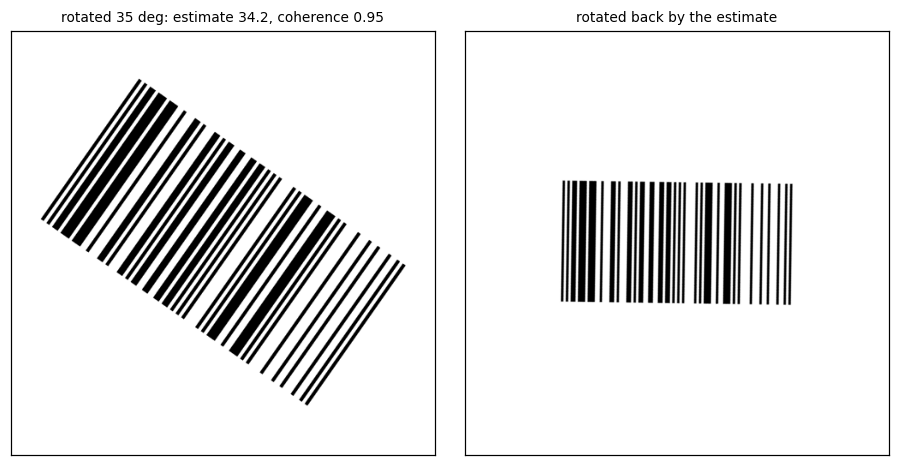

In [31]:
def dominant_orientation(gray):
    """-> (angle of dominant gradient direction, deg; coherence 0..1)."""
    g = gray.astype(np.float64)
    gx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
    j11, j22, j12 = (gx * gx).sum(), (gy * gy).sum(), (gx * gy).sum()
    angle = 0.5 * np.arctan2(2 * j12, j11 - j22)
    coherence = np.sqrt((j11 - j22) ** 2 + 4 * j12 ** 2) / (j11 + j22 + 1e-12)
    return np.degrees(angle), coherence


est, coh = dominant_orientation(rot35)
fixed = rotate_image(rot35, est)
show([rot35, fixed],
     [f"rotated 35 deg: estimate {est:.1f}, coherence {coh:.2f}",
      "rotated back by the estimate"], size=4.2)


Note what the estimate *cannot* tell apart: the tensor squares the gradients, so an angle
and that angle + 180 are the same to it (bars have no arrow). The answer lives in
(-90, 90], and "de-rotated" may mean "de-rotated upside down" - which our bidirectional
decoder from section 3 absorbs without noticing. The two halves of the notebook lock
together.

Sweep every orientation and decode after de-rotating:


In [32]:
print(f"{'true angle':>10} {'estimate':>10} {'coherence':>10} {'decoded':>9}")
n_ok = 0
sweep = range(0, 180, 10)
for a in sweep:
    rot = rotate_image(demo_img, -a)
    est, coh = dominant_orientation(rot)
    fixed = rotate_image(rot, est)
    res = vote_lines(fixed, lambda im, r: cascade_line(
        band_scan(im, r), decoder=decode_scanline_search))
    n_ok += res == DEMO_EAN
    print(f"{a:>10} {est:>10.2f} {coh:>10.3f} {str(res == DEMO_EAN):>9}")
print(f"decoded after de-rotation: {n_ok} / {len(list(sweep))}")


true angle   estimate  coherence   decoded


         0       0.00      0.949      True


        10       9.12      0.947      True


        20      18.74      0.945      True


        30      28.90      0.946      True
        40      39.57      0.947      True


...

       130     -50.43      0.947      True


       140     -39.56      0.947      True


       150     -28.90      0.946      True


       160     -18.74      0.945      True


       170      -9.12      0.947      True
decoded after de-rotation: 18 / 18


## 6. Localization - finding the barcode in a scene

So far the barcode filled the image. In a real photo it is a small patch surrounded by
package art, text, table edges. We need to *find* it before we can read it.

Test scenes first - a pasted, rotated barcode over textured backgrounds (including a page
of printed text, the classic false-positive bait, since text is also high-frequency
stripes). Synthetic scenes mean known ground truth at every angle.


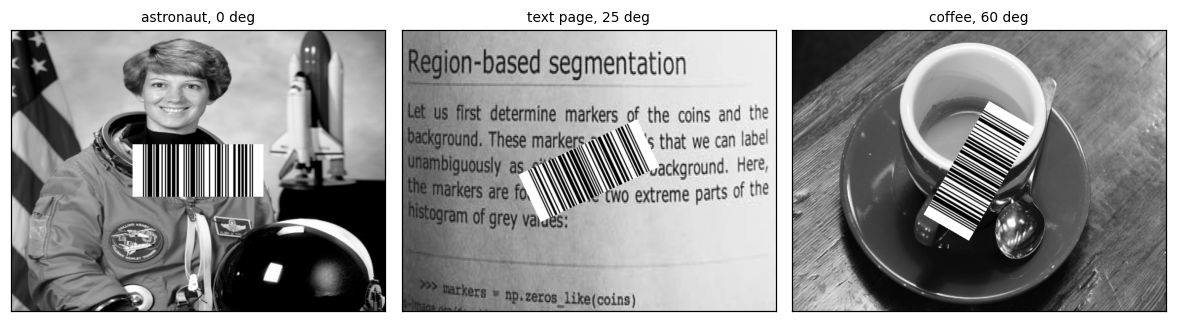

In [33]:
from skimage import data as skdata


def get_backgrounds():
    bgs = [cv2.cvtColor(skdata.astronaut(), cv2.COLOR_RGB2GRAY),
           cv2.cvtColor(skdata.coffee(), cv2.COLOR_RGB2GRAY),
           cv2.cvtColor(skdata.chelsea(), cv2.COLOR_RGB2GRAY),
           skdata.camera(),
           skdata.page()]                       # printed text - the evil one
    return bgs


def compose_scene(bg, ean, angle_deg, scale_w=0.35, pos=(0.5, 0.5)):
    """800x600 scene with a rotated barcode pasted at pos. -> scene"""
    scene = cv2.resize(bg, (800, 600), interpolation=cv2.INTER_AREA).copy()
    barcode = render(encode_ean13(ean), module_px=4, height_px=180)
    s = int(800 * scale_w) / barcode.shape[1]
    barcode = cv2.resize(barcode, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
    rot = rotate_image(barcode, angle_deg)
    mask = rotate_image(np.full(barcode.shape, 255, np.uint8), angle_deg, border=0) > 127
    h, w = rot.shape
    y0, x0 = int(600 * pos[1]) - h // 2, int(800 * pos[0]) - w // 2
    scene[y0:y0 + h, x0:x0 + w][mask] = rot[mask]
    return scene


rng = np.random.default_rng(SEED)
bgs = get_backgrounds()
demo_scenes = [compose_scene(bgs[i], random_ean(rng), a)
               for i, a in [(0, 0), (4, 25), (1, 60)]]
show(demo_scenes, ["astronaut, 0 deg", "text page, 25 deg", "coffee, 60 deg"], size=3.6)


### The classic trick: horizontal minus vertical gradient

The textbook OpenCV recipe for (upright) barcodes exploits the stripe anisotropy
directly: compute `|gx| - |gy|` per pixel. Inside the barcode `|gx|` is huge and `|gy|`
tiny, so the difference glows; on most textures the two roughly cancel. Then blur the
response into blobs, threshold, close the gaps between bars with a wide morphological
kernel, and take the largest contour's `minAreaRect`.

One subtlety worth seeing in the code: `convertScaleAbs` takes the **absolute value** of
the difference. That makes the response symmetric - a 90-degree barcode (gradients all
vertical) glows just as brightly as an upright one. An accident of implementation gives
the "upright-only" method a second orientation for free. Keep that in mind when we
measure.

Calibrate one more expectation before the figure: the box this recipe produces is
*generous*, not tight - the blur / close / erode stages trade precision for never
splitting the barcode into pieces, and the decoder downstream does not care about a
loose crop.


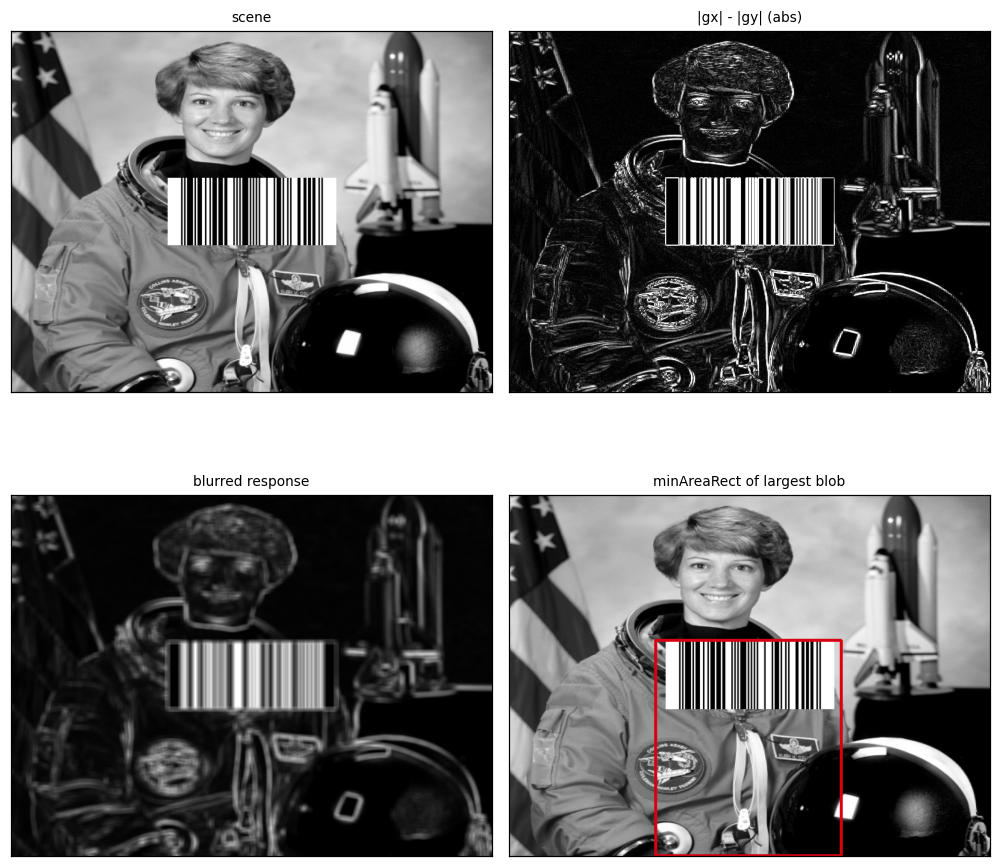

In [34]:
def localize_classic(gray, close_kernel=(21, 7)):
    g = gray.astype(np.float64)
    gx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
    grad = cv2.convertScaleAbs(np.abs(gx) - np.abs(gy))     # note the abs!
    blur = cv2.blur(grad, (9, 9))
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    closed = cv2.morphologyEx(th, cv2.MORPH_CLOSE,
                              cv2.getStructuringElement(cv2.MORPH_RECT, close_kernel))
    closed = cv2.erode(closed, None, iterations=4)
    closed = cv2.dilate(closed, None, iterations=4)
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return cv2.minAreaRect(max(cnts, key=cv2.contourArea)) if cnts else None


def draw_rect(gray, rect):
    vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    if rect is not None:
        cv2.drawContours(vis, [cv2.boxPoints(rect).astype(int)], 0, (217, 0, 18), 4)
    return vis


scene = demo_scenes[0]
g = scene.astype(np.float64)
gx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
resp = cv2.convertScaleAbs(np.abs(gx) - np.abs(gy))
show([scene, resp, cv2.blur(resp, (9, 9)), draw_rect(scene, localize_classic(scene))],
     ["scene", "|gx| - |gy| (abs)", "blurred response", "minAreaRect of largest blob"],
     ncols=2, size=4.6)


### The rotation-proof version: coherence as a detector

For arbitrary angles, upgrade with section 5's insight. Compute the structure tensor
**per window** (box-filter the products `gx*gx`, `gy*gy`, `gx*gy` - a running windowed
sum) and get two maps:

- **energy** = J11 + J22: how much gradient lives here (any direction);
- **coherence**: how much the directions *agree*.

A barcode is the conjunction: lots of gradient AND one direction. Text has energy but
mixed directions (letter strokes point everywhere); smooth surfaces have neither. Note
what the classic method's `|gx| - |gy|` really was: a hard-wired coherence test that only
recognises agreement along the two image axes. The tensor version is the same idea with
the axes handed over to the data.

Before the maps, calibrate the two numbers on four hand-picked patches:


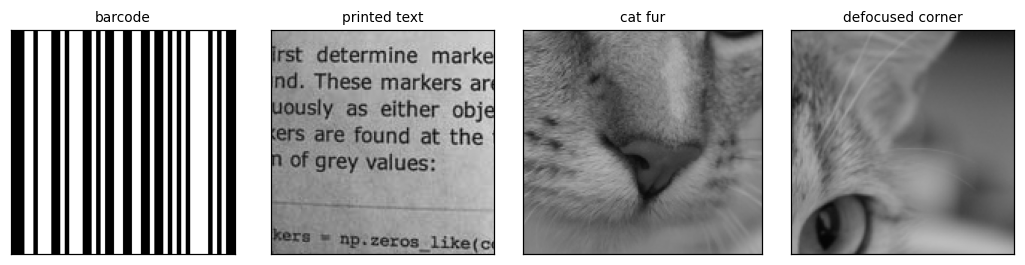

patch             energy/px  coherence
barcode              416160      1.000
printed text          43985      0.137
cat fur                4147      0.164
defocused corner       2662      0.301


In [35]:
patches = {
    "barcode": render(encode_ean13(DEMO_EAN), module_px=3, height_px=150)[:, 60:210],
    "printed text": skdata.page()[40:190, 60:210],
    "cat fur": cv2.cvtColor(skdata.chelsea(), cv2.COLOR_RGB2GRAY)[160:300, 180:330],
    "defocused corner": cv2.cvtColor(skdata.chelsea(), cv2.COLOR_RGB2GRAY)[0:150, 290:440],
}
show(list(patches.values()), list(patches), size=2.4)

print(f"{'patch':<16} {'energy/px':>10} {'coherence':>10}")
for name, p in patches.items():
    gp = p.astype(np.float64)
    gxp = cv2.Sobel(gp, cv2.CV_64F, 1, 0, ksize=3)
    gyp = cv2.Sobel(gp, cv2.CV_64F, 0, 1, ksize=3)
    _, coh = dominant_orientation(p)
    print(f"{name:<16} {(gxp ** 2 + gyp ** 2).mean():>10.0f} {coh:>10.3f}")


Three lessons in one small table. **Energy** separates the patches with edges (barcode,
text) from the soft ones (fur, defocus) - but cannot tell a barcode from a paragraph.
**Coherence** can: the barcode's gradients agree almost perfectly (~1.0), while text
strokes and fur point every which way (~0.14-0.16). And the last row carries a warning:
the defocused corner - the patch with the *least* structure of all - reports the
*highest* non-barcode coherence (~0.3). **Where energy is tiny, coherence is a ratio of
noise and its value means nothing.** That is why the detector demands high energy AND
high coherence, and checks energy first.


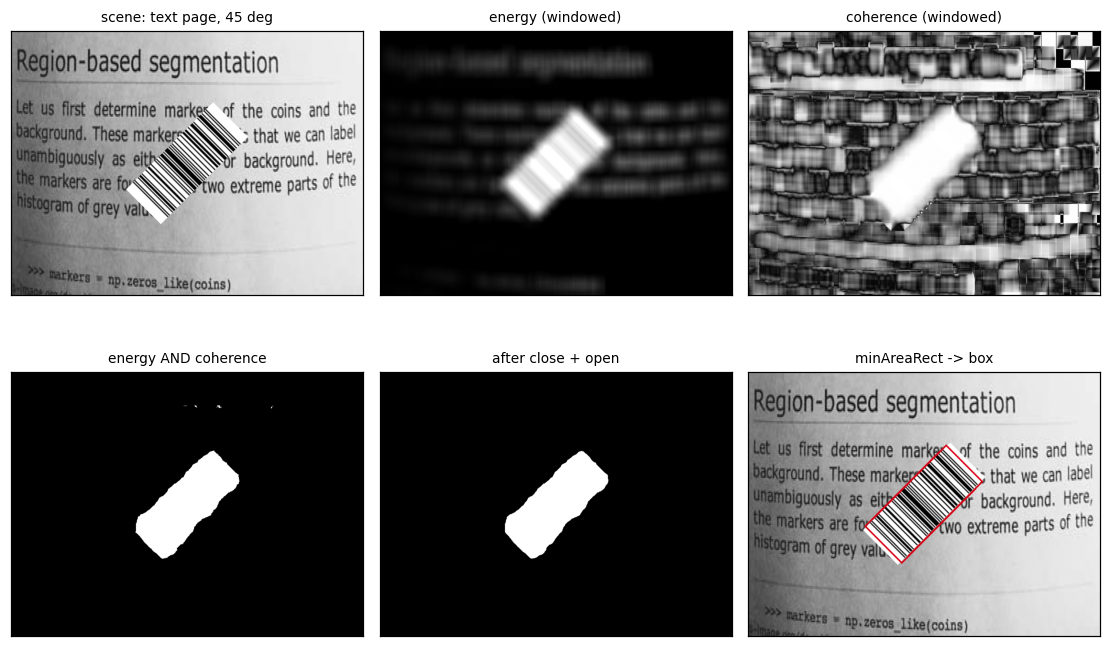

In [36]:
def tensor_maps(gray, win=31):
    g = gray.astype(np.float64)
    gx = cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
    j11 = cv2.boxFilter(gx * gx, -1, (win, win))
    j22 = cv2.boxFilter(gy * gy, -1, (win, win))
    j12 = cv2.boxFilter(gx * gy, -1, (win, win))
    energy = j11 + j22
    coherence = np.sqrt((j11 - j22) ** 2 + 4 * j12 ** 2) / (energy + 1e-12)
    return energy, coherence


def localize_tensor(gray, win=31, energy_q=0.90, coh_min=0.85):
    energy, coherence = tensor_maps(gray, win)
    mask = ((energy > np.quantile(energy, energy_q)) &
            (coherence > coh_min)).astype(np.uint8) * 255
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,
                            cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return cv2.minAreaRect(max(cnts, key=cv2.contourArea)) if cnts else None


scene45 = compose_scene(bgs[4], random_ean(rng), 45)     # text page, worst angle
energy, coherence = tensor_maps(scene45)
raw_mask = ((energy > np.quantile(energy, 0.90)) &
            (coherence > 0.85)).astype(np.uint8) * 255
closed = cv2.morphologyEx(raw_mask, cv2.MORPH_CLOSE,
                          cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15)))
cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN,
                           cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9)))
show([scene45,
      np.clip(energy / np.quantile(energy, 0.99) * 255, 0, 255).astype(np.uint8),
      (coherence * 255).astype(np.uint8),
      raw_mask, cleaned, draw_rect(scene45, localize_tensor(scene45))],
     ["scene: text page, 45 deg", "energy (windowed)", "coherence (windowed)",
      "energy AND coherence", "after close + open", "minAreaRect -> box"],
     ncols=3, size=3.4)


Read the top row left to right: the text page *lights up* in energy - it would fool an
edge-density detector - but stays dark in coherence, while the barcode is bright in both.
The bottom row is the housekeeping: AND the two thresholded maps (a few stray flecks
survive), then a morphological **close** welds the barcode region into one blob and an
**open** dissolves anything smaller than the kernel, leaving `minAreaRect` a single
clean contour to wrap - angle included.

Now the measurement. Both localizers, five backgrounds, easy angles {0, 15, 40, 70, 90}
and the diagonal {42, 45, 48} where `|gx| ~ |gy|` should erase the classic response.
Score = correct end-to-end decode of the located box (crop and orient with the tools we
already have).


In [37]:
def crop_rect(gray, rect, pad=1.6):
    """Cut the (padded) minAreaRect out, long side horizontal."""
    (cx, cy), (w, h), ang = rect
    w, h = w * pad, h * pad
    if w < h:
        w, h = h, w
        ang += 90
    M = cv2.getRotationMatrix2D((cx, cy), ang, 1.0)
    rotated = cv2.warpAffine(gray, M, (gray.shape[1], gray.shape[0]), borderValue=255)
    x0, y0 = max(0, int(cx - w / 2)), max(0, int(cy - h / 2))
    return rotated[y0:int(cy + h / 2), x0:int(cx + w / 2)]


def decode_image(img, n_lines=21):
    """Band + cascade + search + vote -> (ean or None, votes)."""
    votes = Counter()
    for r in np.linspace(img.shape[0] * 0.08, img.shape[0] * 0.92, n_lines).astype(int):
        res = cascade_line(band_scan(img, r), decoder=decode_scanline_search)
        if res is not None:
            votes[res] += 1
    return votes.most_common(1)[0] if votes else (None, 0)


def locate_and_decode(scene, localizer):
    rect = localizer(scene)
    if rect is None:
        return None
    crop = crop_rect(scene, rect)
    if crop.size == 0:
        return None
    ang, _ = dominant_orientation(crop)
    if abs(ang) > 2:
        crop = rotate_image(crop, ang)
    res, v = decode_image(crop)
    if res is None:
        res, v = decode_image(rotate_image(crop, 90))
    return res


rng = np.random.default_rng(SEED)
for title, angles in [("easy angles 0/15/40/70/90", (0, 15, 40, 70, 90)),
                      ("diagonal 42/45/48", (42, 45, 48))]:
    n = nc = nt = 0
    for bg in bgs:
        for a in angles:
            ean = random_ean(rng)
            scene = compose_scene(bg, ean, a)
            nc += locate_and_decode(scene, localize_classic) == ean
            nt += locate_and_decode(scene, localize_tensor) == ean
            n += 1
    print(f"{title:<28} classic {nc:>2}/{n}    tensor {nt:>2}/{n}")


easy angles 0/15/40/70/90    classic 25/25    tensor 25/25


diagonal 42/45/48            classic  7/15    tensor 15/15


As predicted by the arithmetic, not by folklore: the classic method holds up at 0 and 90
(the abs() accident) and at intermediate angles on these mild backgrounds, but **near 45
degrees `|gx| - |gy|` genuinely cancels** and it loses roughly half the scenes. The
tensor localizer does not care about the angle - agreement is agreement in any direction.


## 7. The full pipeline

Assemble everything, with two engineering touches the real photos will justify:

- **Multi-scale localization.** The tensor window (31 px) must roughly match the bar
  spacing. A close-up barcode with 40 px bars fragments a 31 px window's coherence map -
  so on failure, retry with windows 61 and 121.
- **A minimum-vote gate.** Remember the 1-in-10 footnote from section 1: hammer enough
  garbage scanlines against the check digit and eventually one passes. Demand at least 3
  agreeing scanlines before believing a read; if everything fails, fall back to treating
  the *whole image* as the crop (for photos where the barcode fills the frame).

One small dial also moves: the pipeline decodes 41 scanlines per crop instead of the
bench's 21 - crops cut from photos are messier than our rendered test images, and
scanlines are cheap.

Every stage can fail; every failure falls through to the next idea; only a triple-
confirmed read gets out. Then re-run the section 6 bench end-to-end as a regression.


In [38]:
def orient_and_decode(patch, min_votes=3, n_lines=41):
    ang, _ = dominant_orientation(patch)
    if abs(ang) > 2:
        patch = rotate_image(patch, ang)
    res, v = decode_image(patch, n_lines=n_lines)
    if res is None or v < min_votes:
        res2, v2 = decode_image(rotate_image(patch, 90), n_lines=n_lines)
        if v2 > v:
            res, v = res2, v2
    return (res, v) if res is not None and v >= min_votes else (None, v)


def read_barcode(img, min_votes=3):
    """Photo in, EAN out. Returns (ean or None, how-it-was-found)."""
    if img.ndim == 3:                               # a student's own photo, still in color
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    for win in (31, 61, 121):                       # multi-scale localization
        rect = localize_tensor(img, win=win)
        if rect is None:
            continue
        crop = crop_rect(img, rect, pad=1.6)
        if crop.size == 0:
            continue
        res, v = orient_and_decode(crop, min_votes=min_votes)
        if res is not None:
            return res, f"localized (win={win}), {v} votes"
    res, v = orient_and_decode(img, min_votes=min_votes)   # whole-image fallback
    if res is not None:
        return res, f"whole image, {v} votes"
    return None, "failed"


rng = np.random.default_rng(SEED)
ok = n = 0
for bg in bgs:
    for a in (0, 15, 45, 70, 90):
        ean = random_ean(rng)
        res, how = read_barcode(compose_scene(bg, ean, a))
        ok += res == ean
        n += 1
print(f"synthetic scenes, end to end: {ok} / {n}")


synthetic scenes, end to end: 25 / 25


## 8. Real photos

Six photos of real products, from Wikimedia Commons (committed in `data/barcode/`,
downscaled; `_sources.json` maps each to its Commons page):

- a **Coke can** - curved metal, and a chance to test the prefix table;
- a **beer can photographed vertically** - the orientation act, on real data;
- a **tea box close-up** - the barcode fills the frame, at an angle, with perspective;
- a **milk carton** - small and slightly tilted;
- a **strawberry pack from a Taiwan Carrefour** - special: its filename on Commons
  contains the true EAN, so we have real ground truth;
- a **Spitfire ale bottle** - the barcode wraps around the curve of the bottle. Spoiler:
  the bottle beats us.


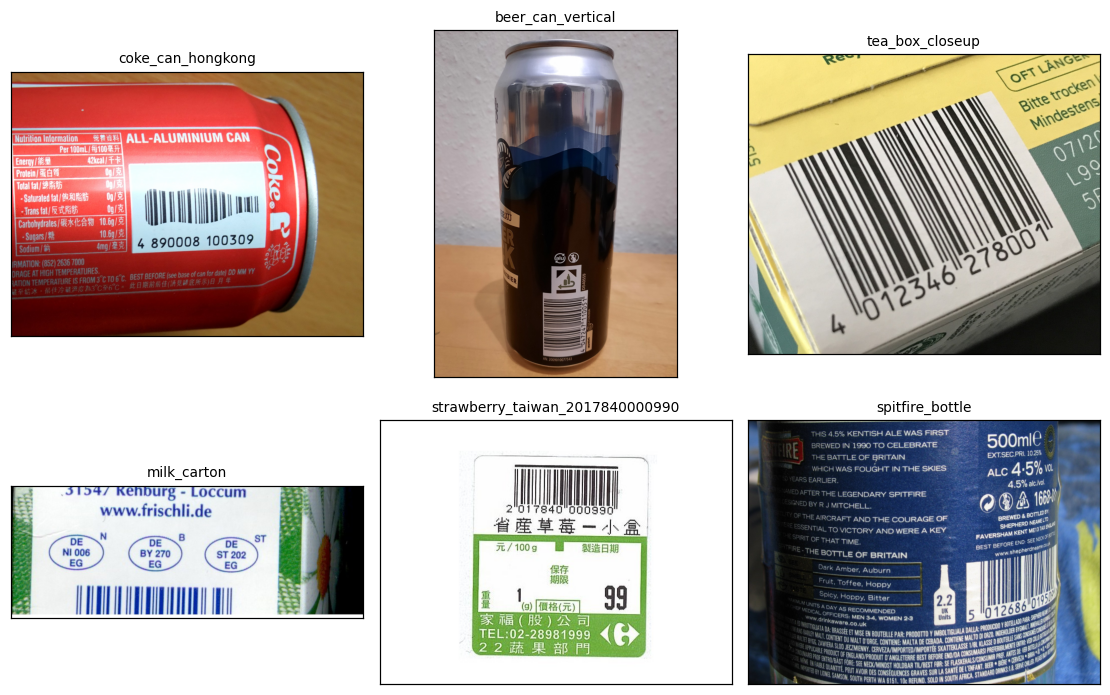

In [39]:
DATA_DIR = Path("data/barcode")
RAW_URL = ("https://raw.githubusercontent.com/HaykTarkhanyan/"
           "python_math_ml_course/main/ml/ch6_cnn/data/barcode/")
PHOTOS = ["coke_can_hongkong.jpg", "beer_can_vertical.jpg", "tea_box_closeup.jpg",
          "milk_carton.jpg", "strawberry_taiwan_2017840000990.jpg",
          "spitfire_bottle.jpg"]


def load_photo(name, gray=True):
    """Local checkout first; on Colab, download from the course repo."""
    p = DATA_DIR / name
    if not p.exists():
        p.parent.mkdir(parents=True, exist_ok=True)
        req = Request(RAW_URL + name, headers={"User-Agent": "Mozilla/5.0"})
        p.write_bytes(urlopen(req).read())
    flag = cv2.IMREAD_GRAYSCALE if gray else cv2.IMREAD_COLOR
    img = cv2.imdecode(np.fromfile(str(p), dtype=np.uint8), flag)
    if img is None:
        raise IOError(f"could not decode {p}")
    return img if gray else cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


show([load_photo(n, gray=False) for n in PHOTOS],
     [n.replace(".jpg", "") for n in PHOTOS], ncols=3, size=3.4)


In [40]:
results = {}
for name in PHOTOS:
    img = load_photo(name)
    t0 = time.perf_counter()
    res, how = read_barcode(img)
    dt = time.perf_counter() - t0
    results[name] = res
    print(f"{name:<40} -> {str(res):<15} ({how}, {dt:.1f} s)")


coke_can_hongkong.jpg                    -> 4890008100309   (localized (win=31), 17 votes, 2.2 s)


beer_can_vertical.jpg                    -> 4047247110051   (localized (win=31), 11 votes, 2.4 s)


tea_box_closeup.jpg                      -> 4012346278001   (localized (win=121), 12 votes, 7.3 s)


milk_carton.jpg                          -> 4045500011039   (localized (win=31), 41 votes, 0.6 s)


strawberry_taiwan_2017840000990.jpg      -> 2017840000990   (localized (win=31), 30 votes, 0.8 s)


spitfire_bottle.jpg                      -> None            (failed, 15.5 s)


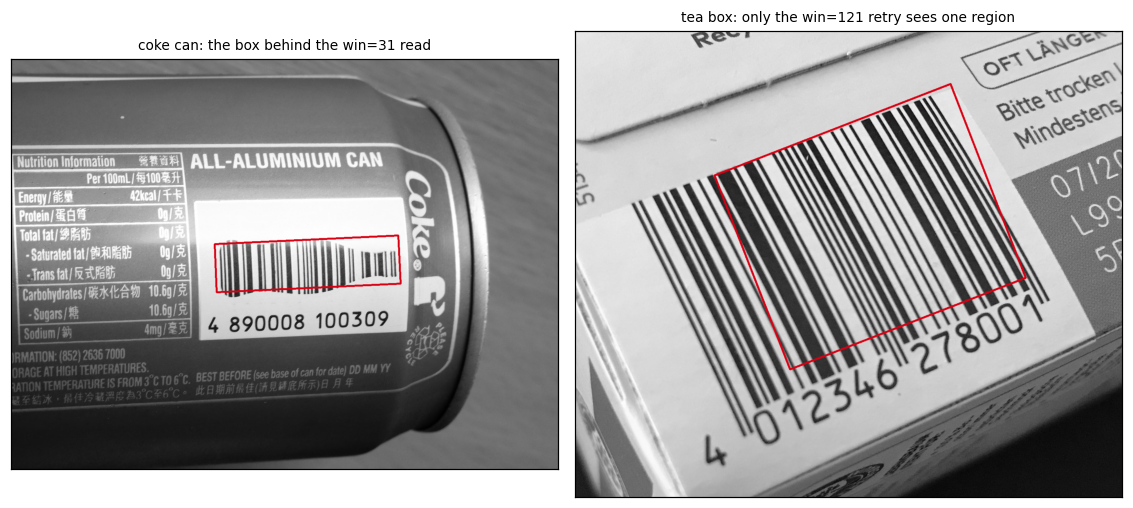

In [41]:
coke = load_photo("coke_can_hongkong.jpg")
tea = load_photo("tea_box_closeup.jpg")
show([draw_rect(coke, localize_tensor(coke)),
      draw_rect(tea, localize_tensor(tea, win=121))],
     ["coke can: the box behind the win=31 read",
      "tea box: only the win=121 retry sees one region"], size=5.2)


Five out of six - and the boxes above show the pipeline is reading the barcode, not
getting lucky. The reads hold up against every check we have:

- the **strawberry pack** decodes to exactly the EAN recorded in its Commons filename -
  a genuine ground-truth match on a photo we never touched;
- the **Coke can** starts with 489 - the GS1 prefix of **Hong Kong**, so the code was
  issued there (485 would have made it Armenian). The prefix table is a plausibility check that
  works on any read;
- the **beer can** was photographed vertically - nothing special-cases that: the crop
  comes out long-side-horizontal by construction, and `orient_and_decode` tries the
  perpendicular direction whenever the first one fails;
- the **tea box** needed the multi-scale retry: its close-up bars are far wider than the
  31 px default window, and only the win=121 pass produces a clean box. (It also carries
  visible perspective - module widths shrink toward the far side. Nobody handled that
  explicitly: the per-digit normalisation from section 3 absorbs a slow width drift,
  because each digit renormalises to its own 7 modules.)

One claim from section 4 deserves a live demonstration on real data: **resolution**.
The beer can is committed at a 2000 px longest side. Shrink it and read again:


In [42]:
beer = load_photo("beer_can_vertical.jpg")
for max_side in (2000, 1400):
    s = max_side / max(beer.shape)
    img = beer if s >= 1 else cv2.resize(beer, None, fx=s, fy=s,
                                         interpolation=cv2.INTER_AREA)
    res, how = read_barcode(img)
    print(f"longest side {max_side} px -> {str(res):<15} ({how})")


longest side 2000 px -> 4047247110051   (localized (win=31), 11 votes)


longest side 1400 px -> None            (failed)


Same photo, same pipeline - a third fewer pixels and the read dies outright. That is
section 4's blur-wall lesson (resolution beats cleverness) with no blur involved: the
thinnest bars simply run out of pixels.

Which leaves the Spitfire bottle - and it deserves its own autopsy.


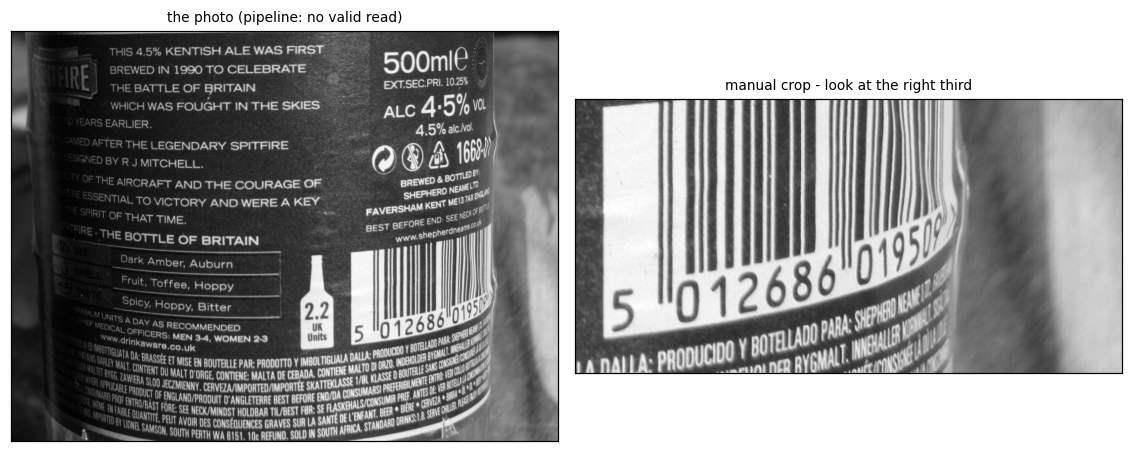

decode of the generous manual crop: None  (votes: 0)


In [43]:
spit = load_photo("spitfire_bottle.jpg")
crop = spit[560:840, 840:1400]         # generous manual crop around the barcode
show([spit, crop], ["the photo (pipeline: no valid read)",
                    "manual crop - look at the right third"], ncols=2, size=5.2)
res, v = orient_and_decode(crop, min_votes=1)
print(f"decode of the generous manual crop: {res}  (votes: {v})")


The failure is not the localizer - even a hand-drawn box does not decode. Look at the
right third of the crop: the label **wraps around the curve of the bottle**, so the last
digits compress from ~7 modules of width toward nearly edge-on. Our per-digit
normalisation forgives *slow* drift (the tea box), but here the compression changes
*within* single digits, and the run-width ratios themselves are destroyed. A straight
scanline through a cylinder's silhouette is sampling a cosine-squashed signal; the
information is gone at sampling time - blur's evil cousin. (Real scanner apps sweep many
sampling *curves*, not just rows, and win some of these back.)

**The lie the pipeline did NOT tell.** Watch what happens if we drop the 3-vote gate and
let the whole-image fallback loose on this photo:


In [44]:
res, v = orient_and_decode(spit, min_votes=1)
print(f"whole image, min_votes=1: {res}  (votes: {v})")
print(f"the label actually reads:  5012686019509")


whole image, min_votes=1: 0103013520227  (votes: 1)
the label actually reads:  5012686019509


A checksum-valid EAN that matches nothing on the bottle. Mechanics: dozens of scanlines
through dense label text, each with a sliding 59-run search, is thousands of parse
attempts against a filter that passes 1 in 10 random strings - some lone fluke
eventually gets through. One vote, zero corroboration, confidently wrong.

This is the **multiple-comparisons problem** wearing a barcode costume: run enough tests
against a soft filter and you will manufacture a positive. The 3-vote gate is our
Bonferroni - a real read is confirmed by many scanlines, a fluke never repeats. The
pipeline answering "failed" on this photo is not a weakness; it is the difference
between a measurement and a guess.


## 9. The industrial baseline

OpenCV ships a production barcode reader (`cv2.barcode.BarcodeDetector`, added in
OpenCV 4.5.3; its optional super-resolution stage reuses models from WeChat's QR
scanner). Same six photos, their code against our notebook:


In [45]:
det = cv2.barcode.BarcodeDetector()
print(f"{'photo':<40} {'ours':<16} {'cv2.barcode':<16}")
print("-" * 72)
n_ours = n_cv = 0
for name in PHOTOS:
    img = load_photo(name)
    t0 = time.perf_counter()
    ok, infos, types, corners = det.detectAndDecodeWithType(img)
    dt_cv = time.perf_counter() - t0
    cv_res = next((s for s in (infos or ()) if s), None)
    n_ours += results[name] is not None
    n_cv += cv_res is not None
    print(f"{name:<40} {str(results[name]):<16} {str(cv_res):<16} ({dt_cv * 1000:.0f} ms)")
print(f"\ntotal decoded:  ours {n_ours}/6,  cv2 {n_cv}/6")


photo                                    ours             cv2.barcode     
------------------------------------------------------------------------
coke_can_hongkong.jpg                    4890008100309    None             (67 ms)
beer_can_vertical.jpg                    4047247110051    4047247110051    (28 ms)


tea_box_closeup.jpg                      4012346278001    4012346278001    (51 ms)
milk_carton.jpg                          4045500011039    None             (16 ms)
strawberry_taiwan_2017840000990.jpg      2017840000990    2017840000990    (37 ms)
spitfire_bottle.jpg                      None             None             (22 ms)

total decoded:  ours 5/6,  cv2 3/6


Ours: 5/6. The industrial detector: 3/6 on the same images - it agrees with us on
the strawberry, tea box and beer can, misses the **Coke can** and the **milk carton**
that our pipeline reads, and also fails on the Spitfire.

Before celebrating, be fair about what this does and does not show. Six photos is not a
benchmark; and the cv2 detector runs in *milliseconds* against our *seconds* - a budget
that says it is meant for live video, where a failed frame costs nothing because the
next frame arrives immediately - so per frame it gives up much earlier than we do. The honest
conclusions are narrower and more interesting:

- a from-scratch pipeline where you understand every stage can genuinely compete on
  accuracy, per frame, with an industrial one - because it can afford to try harder;
- when the black box fails you have nothing to turn; when *this* notebook's reader
  fails, section 8's autopsy told us exactly which assumption broke and what buying a
  better read would cost.


## Wrap-up - what to take with you

**The pipeline you built:**

| stage | tool | the idea that powers it |
|---|---|---|
| localize | Sobel + structure tensor, per window | barcode = high gradient energy AND one direction |
| orient | structure tensor, whole patch | gradients point across the bars; squaring kills the sign |
| binarize | global -> adaptive cascade | every threshold is a bet; the checksum referees the cascade |
| digitize | runs -> normalised widths | widths divide out scale; each digit is its own ruler |
| frame | sliding 59-run window | never trust framing; search for structure |
| decode | signature matching + parity | the 13th digit hides in *how* digits are encoded |
| verify | check digit + 3-vote gate | soft filters need corroboration |

**The five transferable lessons**, none of them barcode-specific:

1. **Measure before you fix.** Every mechanism in section 4 entered the pipeline
   attached to a before/after table; the one "obvious" fix we tried (the adaptive
   threshold) turned out to break more than it repaired, and only the measurement
   caught it.
2. **Redundancy is a design material.** Vertical bars bought band-averaging; three
   digit alphabets bought direction detection and a free 13th digit; the check digit
   bought fearless cascading. When you design a format, redundancy is where robustness
   comes from.
3. **Resolution beats cleverness.** Blur at the module scale, the shrunken beer can,
   and the bottle's curvature all destroyed information *before* the software ran. No downstream
   fix recovers what sampling lost - move the camera instead.
4. **Soft filters + many attempts = manufactured positives.** The 1-in-10 checksum
   plus thousands of window parses produced a confident lie; the vote gate is the
   statistical correction. You will meet this again far from barcodes - it is the
   same trap as p-hacking.
5. **Know when the world is on your side.** Everything here worked *because barcodes
   were designed to be read*: quiet zones, guards, self-scaling widths, parity, the
   checksum. HW1c's biopsy had none of these, and the same toolkit collapsed.

**Where CNNs pick up.** This chapter's argument in one line: hand-designed features win
when the pattern was designed for the machine, and lose when it was not. The gradient
machinery you used all through this notebook does not get discarded - a learned conv1
layer builds the same oriented-edge detectors (L17 shows them), and detection networks
(L19: YOLO and friends) are, at heart, learned localizers producing the same boxes as
our structure tensor, for objects nobody printed guard bars on.

**Going further, if this itched:**

- decode **UPC-A** with the tools you already have (it is EAN-13 with first digit 0 -
  how few lines do you need to change?);
- the natural next format is the **QR code**: 2D, finder patterns instead of guard
  bars, and instead of a check digit that merely *detects* errors, Reed-Solomon codes
  that *correct* them - that is why a QR code at its highest correction level still
  scans with up to ~30% of it covered by a sticker;
- point `read_barcode` at your own shelf: photograph five products and see which
  assumptions of this notebook your kitchen violates. If you find an Armenian product,
  it should start with 485.
